# EDA, definición de churn y modelo de recompra — Olist
### Sprints 1 – 3 · Datos CSV leídos desde Azure Blob Storage público

**Análisis de propensión al churn de clientes · Olist Brazilian E-Commerce (Caso Nº 7)**
**Módulo:** Implementación de Soluciones de IA Aplicada a los Negocios
**Autor:** Nelson De La Quintana · Junio 2026

> ✅ **Compatible con VS Code y Google Colab.** Los datos se leen con `pandas` por HTTPS directamente
> del contenedor público `olist-data` de la cuenta `oliststorage40548` (lectura anónima: sin password,
> sin SAS y sin SDK de Azure). Respaldo teórico y metodológico: `olist_churn.docx`.

---

### Resumen ejecutivo

- **Pregunta de negocio:** ¿qué clientes primerizos tienen mayor propensión a hacer su **2ª compra**
  (y, por complemento, cuáles abandonan), para accionar campañas de conversión con presupuesto acotado?
- **Decisiones clave:** target `is_repeat` (2ª compra dentro de **H = 90 días**) sobre la población de
  **primerizos** (`frequency = 1`), en lugar del `is_churn` por ventana (degenerado: ~97–99 % positivos);
  partición **out-of-time** por snapshots mensuales (train 2017 · validation 2018-Q1 · backtest 2018-Q2);
  selección de variables por **embudo** (filtros → VIF → embebidos → wrapper → consenso de rangos);
  las señales post-compra del 1er pedido (reseña, retraso) se mantienen como **control**, no como features.
- **Resultados principales:** existe señal y el pipeline funciona de extremo a extremo. Se comparan
  Dummy, regresión logística balanceada, Random Forest y HistGradientBoosting; el mejor se elige por
  AUC out-of-time, se **optimiza por hiperparametrización con validación cruzada walk-forward** (§11.b)
  y se evalúa **una sola vez** en backtest, traduciendo el resultado a lift por decil, curva de ganancia
  y valor estimado de campaña (§10–§14).

### Resumen por Sprint · lista de actos

| Sprint | Foco | Actos | Secciones | Entregable |
|---|---|---|---|---|
| **🟩 1 — Definición y EDA** | Problema, hipótesis, EDA, target preliminar y partición sin fuga | I · II · III · IV | 1–8 | Notebook con EDA + baseline · target preliminar · hipótesis y hallazgos |
| **🟨 2 — Ingeniería y pipeline** | Selección de variables, pipeline reproducible, métricas finales y simulación de actualización mensual | V *(parte)* | 9 · 13–14 · 18–19 | Pipeline modular y reproducible · métricas versión-pipeline · simulación de retraining mensual |
| **🟧 3 — Modelo final** | Modelos candidatos, **hiperparametrización + CV**, backtest, importancia de variables y artefacto | V *(parte)* | 10–12 · 11.b · 12.b · 15–17 | Modelo optimizado (`.pkl`) · métricas definitivas · feature importance · target final |

> El Acto V se reparte entre el Sprint 2 (ingeniería del pipeline y operación mensual) y el Sprint 3
> (modelado, optimización y artefacto). La **simulación mensual (§18–19, Sprint 2)** cierra el notebook
> porque consume el artefacto exportado en el Sprint 3; en producción es el **job de Databricks**
> (`Azure/Databricks/olist_train_pipeline.py`, día 1 de cada mes) el que ejecuta esa lógica.

### El libro en cinco actos

| Acto | Sprint | Secciones | Pregunta que responde |
|---|---|---|---|
| **I. Los cimientos** | 1 | 1–3 | ¿Qué problema resolvemos y de qué datos disponemos? |
| **II. El casting de variables** | 1 | 4 | ¿Qué candidatas existen y cuáles podemos crear? |
| **III. Conocer al cliente** | 1 | 5–6 | ¿Cómo pasamos de 9 tablas a una fila por cliente y quién compra? |
| **IV. El problema bien planteado** | 1 | 7–8 | ¿Qué predecimos, sobre quiénes y cómo particionamos sin fuga? |
| **V. El embudo, el modelo y la decisión** | 2 y 3 | 9–19 | ¿Qué variables sirven, qué modelo gana (ya optimizado) y cuánto vale? |

*Ninguna sección usa información posterior a la fecha de corte `t`; el backtest se toca una sola vez.*


## Trabajos relacionados (estado del arte)

La predicción de churn y de recompra es un problema ampliamente estudiado. El trabajo más cercano a este proyecto es **Liu et al. (2016, KDD)**, que predice qué compradores nuevos recomprarán dentro de seis meses —exactamente la formulación de `is_repeat`—, con tasa base ~6 % resuelta con feature engineering y ensembles. El encuadre churn↔recompra se apoya en el modelo **BG/NBD** de **Fader, Hardie y Lee (2005)**, y la evaluación por **lift y curva de ganancia** sigue a **Neslin et al. (2006)** y **Verbeke et al. (2012)**.

| Referencia | Aporte principal | Dónde se aplica |
|---|---|---|
| Liu et al. (2016), KDD | Repeat-buyer prediction (~6 % recompra) con feature engineering + ensembles | Sprint 1 (target) · Sprint 2 (features) |
| Fader, Hardie & Lee (2005) | BG/NBD: recompra en entornos no contractuales | Sprint 1 (framing churn↔recompra) |
| Neslin et al. (2006) | Evaluación por lift / curva de ganancia | Sprint 3–4 (KPIs) |
| Verbeke et al. (2012) | Churn rentable; ensembles ganan; métricas de beneficio | Sprint 3–4 |
| Chen & Guestrin (2016) | XGBoost: boosting tabular escalable | Sprint 3 (GB / HistGB) |
| Chawla et al. (2002) | SMOTE para desbalance | Sprint 2–3 (aquí: class_weight) |
| Revisión sistemática (2025), MDPI | Ensembles/boosting dominan; retos de desbalance | Transversal |

> **Nota:** algunos estudios sobre Olist reportan ~99 % de exactitud/AUC en churn; tales cifras alertan de **fuga de información** o target trivial, y motivan nuestras salvaguardas (partición out-of-time, backtest único, features ≤ t). Referencias completas en `olist_churn.docx`.


## Acto I — Los cimientos

> 🟩 **Sprint 1 — Definición del problema y EDA inicial**


### 2. Configuración y reproducibilidad

*¿Puede otro ejecutar esto y obtener lo mismo?* Semillas fijas, versiones impresas y parámetros
globales del experimento (horizonte `H`, rango de snapshots, URL de los datos) declarados en un
solo lugar. La celda siguiente instala dependencias **solo si faltan** (en Colab y en VS Code ya
suelen estar).

In [1]:
# Compatibilidad VS Code / Google Colab: instala dependencias solo si faltan
import importlib.util, sys

REQUIRED = ["pandas", "numpy", "matplotlib", "seaborn", "sklearn", "scipy", "joblib"]
missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    pkgs = [p.replace("sklearn", "scikit-learn") for p in missing]
    for p in pkgs:
        %pip install -q {p}
    print("Instalados:", pkgs, "-> si algun import falla, reinicia el kernel y reejecuta.")
else:
    print("Dependencias OK - no hace falta instalar nada.")
print("Python:", sys.version.split()[0])

Dependencias OK - no hace falta instalar nada.
Python: 3.12.13


In [2]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
# --- Legibilidad de los gráficos: fuentes moderadas y consistentes ---
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.titlesize": 10,      # títulos compactos (evita que los largos se desborden)
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.titlepad": 6,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# --- Parametros globales del experimento (mismos nombres que el job de produccion) ---
BLOB = "https://oliststorage40548.blob.core.windows.net/olist-data"  # publico, sin password
H = 90                            # horizon_days: ventana de resultado (dias)
SNAPSHOT_START = "2017-01-31"     # primer snapshot mensual
SNAPSHOT_END = None               # se fija en la seccion 8 con la regla t + H <= fin de datos
RANDOM_STATE = 42
INVALID_STATUS = ["canceled", "unavailable"]
CUTOFF_DATE_DEMO = pd.Timestamp("2018-05-31")   # snapshot de ejemplo para ilustrar

print("pandas", pd.__version__, "| numpy", np.__version__, "| sklearn", sklearn.__version__)
assert tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 2), \
    "se requiere scikit-learn >= 1.2 (HistGradientBoostingClassifier con class_weight)"


pandas 2.2.2 | numpy 2.0.2 | sklearn 1.6.1


### 3. Carga y auditoría de datos

*¿De qué datos disponemos y en qué estado?* Los CSV están publicados en el contenedor
**`olist-data`** de la cuenta de almacenamiento **`oliststorage40548`** con **acceso anónimo de
lectura a nivel blob** (verificado: `publicAccess = blob`, `allowBlobPublicAccess = true`), por lo
que `pandas` puede leerlos por HTTPS sin credenciales tanto en VS Code como en Colab.

Inventario verificado con el CLI de Azure:

```bash
az storage container show --account-name oliststorage40548 --name olist-data \
    --query properties.publicAccess          # -> "blob"  (lectura anonima)
az storage blob list --account-name oliststorage40548 --container-name olist-data -o table
```

| Archivo (blob) | Tamaño | Contenido |
|---|---:|---|
| `olist_orders_dataset.csv` | 16,8 MB | Pedidos (estado y 5 fechas del ciclo) |
| `olist_order_items_dataset.csv` | 14,7 MB | Ítems: producto, vendedor, precio, flete |
| `olist_order_reviews_dataset.csv` | 13,8 MB | Reseñas 1–5 y texto libre |
| `olist_customers_dataset.csv` | 8,6 MB | Clientes: `customer_unique_id`, CP, ciudad, estado |
| `olist_order_payments_dataset.csv` | 5,5 MB | Pagos: método, cuotas, monto |
| `olist_products_dataset.csv` | 2,3 MB | Productos: categoría, fotos, peso, dimensiones |
| `geolocation_zip_lookup.csv` | 1,1 MB | **Centroide (lat, lng) por prefijo postal** — derivado en el Sprint 1 |
| `olist_sellers_dataset.csv` | 0,2 MB | Vendedores: CP, ciudad, estado |
| `product_category_name_translation.csv` | 2,6 KB | Traducción de categorías PT → EN |
| `olist_geolocation_dataset.csv` | 58,4 MB | Geolocalización cruda — **no se descarga**: la reemplaza el lookup |

**Relaciones entre tablas:** `orders ↔ customers` por `customer_id` · `order_items / order_payments /
order_reviews → orders` por `order_id` · `order_items → products` por `product_id` y `→ sellers` por
`seller_id` · `products → category_translation` por `product_category_name` · cliente y vendedor se
geolocalizan por su prefijo postal contra el lookup.

In [3]:
ORDER_DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

def load_tables(base_url: str = BLOB) -> dict:
    '''Lee los CSV publicados en Azure Blob (HTTPS anonimo) con fechas parseadas.'''
    return {
        "orders": pd.read_csv(f"{base_url}/olist_orders_dataset.csv",
                              parse_dates=ORDER_DATE_COLS),
        "customers": pd.read_csv(f"{base_url}/olist_customers_dataset.csv"),
        "order_items": pd.read_csv(f"{base_url}/olist_order_items_dataset.csv",
                                   parse_dates=["shipping_limit_date"]),
        "order_payments": pd.read_csv(f"{base_url}/olist_order_payments_dataset.csv"),
        "order_reviews": pd.read_csv(f"{base_url}/olist_order_reviews_dataset.csv",
                                     parse_dates=["review_creation_date",
                                                  "review_answer_timestamp"]),
        "products": pd.read_csv(f"{base_url}/olist_products_dataset.csv"),
        "sellers": pd.read_csv(f"{base_url}/olist_sellers_dataset.csv"),
        "category_translation": pd.read_csv(
            f"{base_url}/product_category_name_translation.csv"),
        "geo_lookup": pd.read_csv(f"{base_url}/geolocation_zip_lookup.csv"),
    }

tables = load_tables()
display(pd.DataFrame({name: {"filas": len(df), "columnas": df.shape[1]}
                      for name, df in tables.items()}).T)

,filas,columnas
orders,99441,8
customers,99441,5
order_items,112650,7
order_payments,103886,5
order_reviews,99224,7
products,32951,9
sellers,3095,4
category_translation,71,2
geo_lookup,19015,5


In [4]:
# Diccionario de datos programatico: columna, tipo y % de nulos por tabla
dict_rows = []
for tname, df in tables.items():
    for col in df.columns:
        dict_rows.append({"tabla": tname, "columna": col, "dtype": str(df[col].dtype),
                          "pct_nulos": df[col].isna().mean() * 100})
data_dict = pd.DataFrame(dict_rows)
print(f"{data_dict.shape[0]} columnas en {len(tables)} tablas. Columnas con nulos:")
display(data_dict[data_dict.pct_nulos > 0]
        .sort_values("pct_nulos", ascending=False).reset_index(drop=True))

# Duplicados en las claves declaradas
print("Chequeo de claves:")
print(f"  orders.order_id unico:        {tables['orders'].order_id.is_unique}")
print(f"  customers.customer_id unico:  {tables['customers'].customer_id.is_unique}")
print(f"  products.product_id unico:    {tables['products'].product_id.is_unique}")
print(f"  sellers.seller_id unico:      {tables['sellers'].seller_id.is_unique}")
print(f"  geo_lookup.zip_prefix unico:  "
      f"{tables['geo_lookup'].geolocation_zip_code_prefix.is_unique}")
dup_rev = tables["order_reviews"].review_id.duplicated().sum()
print(f"  order_reviews.review_id duplicados: {dup_rev} "
      "(rareza conocida del dataset: una resena puede cubrir varios pedidos)")

52 columnas en 9 tablas. Columnas con nulos:


,tabla,columna,dtype,pct_nulos
0,order_reviews,review_comment_title,object,88.342
1,order_reviews,review_comment_message,object,58.703
2,orders,order_delivered_customer_date,datetime64[ns],2.982
3,products,product_name_lenght,float64,1.851
4,products,product_category_name,object,1.851
5,products,product_description_lenght,float64,1.851
6,products,product_photos_qty,float64,1.851
7,orders,order_delivered_carrier_date,datetime64[ns],1.793
8,orders,order_approved_at,datetime64[ns],0.161
9,products,product_weight_g,float64,0.006


Chequeo de claves:
  orders.order_id unico:        True
  customers.customer_id unico:  True
  products.product_id unico:    True
  sellers.seller_id unico:      True
  geo_lookup.zip_prefix unico:  True
  order_reviews.review_id duplicados: 814 (rareza conocida del dataset: una resena puede cubrir varios pedidos)


In [5]:
# Rango temporal y resolucion de identidad del cliente
orders = tables["orders"]
print(f"Pedidos: {orders.order_purchase_timestamp.min():%Y-%m-%d} .. "
      f"{orders.order_purchase_timestamp.max():%Y-%m-%d}")
print("\nEstados de pedido:")
print(orders.order_status.value_counts().to_string())

orders_customers = orders.merge(tables["customers"], on="customer_id", how="left")
valid_orders = orders_customers[
    ~orders_customers.order_status.isin(INVALID_STATUS)].copy()

# Error tipico: con customer_id TODOS parecen compradores de una sola vez
by_wrong_id = valid_orders.groupby("customer_id").order_id.nunique()
print(f"\nCon customer_id: max pedidos por 'cliente' = {by_wrong_id.max()} "
      "-> 100% compradores 'unicos' (FALSO: es una clave por pedido)")

orders_per_customer = valid_orders.groupby("customer_unique_id").order_id.nunique()
n_customers = len(orders_per_customer)
repeat_rate_global = (orders_per_customer >= 2).mean()
print(f"\nCon customer_unique_id: {n_customers:,} clientes con pedidos validos")
print(f"  compra unica:          {(orders_per_customer == 1).mean():.2%}")
print(f"  recompra (>=2 pedidos): {repeat_rate_global:.2%}")

repeat_ids = orders_per_customer[orders_per_customer >= 2].index
sales = (valid_orders.merge(tables["order_items"].groupby("order_id", as_index=False)
                            .agg(order_value=("price", "sum")), on="order_id", how="left")
         .assign(is_rep=lambda d: d.customer_unique_id.isin(repeat_ids))
         .groupby("is_rep").order_value.sum())
print(f"  % de las ventas que aportan los recurrentes: {sales[True] / sales.sum():.2%}")

Pedidos: 2016-09-04 .. 2018-10-17

Estados de pedido:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Con customer_id: max pedidos por 'cliente' = 1 -> 100% compradores 'unicos' (FALSO: es una clave por pedido)

Con customer_unique_id: 94,990 clientes con pedidos validos
  compra unica:          96.96%
  recompra (>=2 pedidos): 3.04%
  % de las ventas que aportan los recurrentes: 5.56%


## Acto II — El casting de variables

> 🟩 **Sprint 1 — Definición del problema y EDA inicial**


### 4. Variables directas e ingeniería de adicionales

*¿Qué candidatas existen y cuáles podemos crear?* Inventario completo con su hipótesis asociada.

**Directas** — agregación de columnas crudas por `customer_unique_id` hasta la fecha de corte `t`
(tabla maestra base: RFM + comportamiento + contexto):

| Variable | Origen | Hipótesis / rol |
|---|---|---|
| `recency_days` | orders | A menor recencia, más probable la recompra |
| `frequency` | orders | Constante = 1 en primerizos → morirá en el filtro de varianza |
| `monetary` | items + payments | Mayor gasto inicial → mayor compromiso |
| `tenure_days` | orders | ≡ `recency` en primerizos → morirá por colinealidad |
| `avg_items` | order_items | Pedidos con más ítems → más exploración |
| `avg_order_value` | order_items | Ticket promedio (≈ `monetary` en primerizos) |
| `avg_freight_value` | order_items | Flete alto desincentiva la recompra |
| `max_installments` | order_payments | Cuotas altas → compra planificada, distinta propensión |
| `avg_distance_km` | geolocation | Distancia cliente–vendedor encarece y demora |
| `customer_state` / `top_category` / `payment_type` | varias | Contexto categórico dominante |
| `avg_review_score`, `avg_delay_days`, `pct_late_deliveries` | reviews / orders | **Control** (post-compra del 1er pedido, no features) |

**Adicionales (ingeniería)** — derivadas visibles en el momento de la compra, válidas para primerizos:

| Familia | Variables | Justificación |
|---|---|---|
| Calendario de adquisición | `purchase_month`, `purchase_dow`, `purchase_hour`, `is_high_season` | Estacionalidad de captación (Black Friday/Navidad vs. orgánico) |
| Ratios de valor | `freight_ratio`, `avg_item_price` | Normalizan y rompen la redundancia flete~valor~ítems |
| Canasta | `n_categories` | Diversidad del 1er pedido: exploración vs. compra puntual |
| Calidad del listing | `avg_photos_qty`, `avg_description_len`, `avg_product_weight_g`, `avg_product_volume_cm3` | Tipo y calidad del producto comprado |
| Logística / geografía | `promised_lead_days`, `same_state_seller`, `customer_region` | Plazo prometido visible en `t`; región reduce cardinalidad (27 → 5) |
| Pago | `n_payment_types`, `used_voucher` | Pago multi-método y uso de cupones |

**Regla anti-fuga:** toda feature usa solo pedidos con `order_purchase_timestamp ≤ t`; el target usa
solo la ventana `(t, t+H]`. **Criterio de admisión:** la utilidad de cada candidata se mide contra
`is_repeat` en validación out-of-time (sección 9), nunca en backtest.

In [6]:
# Inventario de candidatas (se materializan en la seccion 5)
DIRECT_NUM = ["recency_days", "tenure_days", "frequency", "monetary", "avg_items",
              "avg_order_value", "avg_freight_value", "max_installments",
              "avg_distance_km"]
CONTROL_NUM = ["avg_review_score", "avg_delay_days", "pct_late_deliveries"]  # post-compra
ENGINEERED_NUM = ["freight_ratio", "avg_item_price", "promised_lead_days",
                  "n_categories", "avg_photos_qty", "avg_description_len",
                  "avg_product_weight_g", "avg_product_volume_cm3",
                  "n_payment_types", "used_voucher", "same_state_seller",
                  "purchase_month", "purchase_dow", "purchase_hour", "is_high_season"]
CAT_CANDIDATES = ["customer_state", "customer_region", "top_category", "payment_type"]
TARGET = "is_repeat"

print(f"Candidatas: {len(DIRECT_NUM)} directas + {len(ENGINEERED_NUM)} de ingenieria + "
      f"{len(CAT_CANDIDATES)} categoricas, mas {len(CONTROL_NUM)} de control")

Candidatas: 9 directas + 15 de ingenieria + 4 categoricas, mas 3 de control


## Acto III — Conocer al cliente

> 🟩 **Sprint 1 — Definición del problema y EDA inicial**


### 5. Vista cliente: `order_enrichment` → tabla maestra

*¿Cómo pasamos de 9 tablas a una fila por cliente?* En dos pasos, espejo de los objetos SQL del
proyecto (`dbo.order_enrichment` y `dbo.sp_build_master_table`):

1. **`build_order_enrichment`** — una fila por **pedido** válido (excluye `canceled`/`unavailable`),
   con valor, flete, categoría dominante, pago, reseña, distancia haversine cliente–vendedor y
   métricas de entrega.
2. **`build_engineered_features`** — las 6 familias de candidatas adicionales a nivel pedido,
   todas visibles en el momento de la compra.
3. **`build_master_table(t, H)`** — función generadora **parametrizada por la fecha de corte `t`**,
   que agrega por `customer_unique_id` con la regla anti-fuga explícita: features con pedidos
   `≤ t`, target con la ventana `(t, t+H]`.

In [7]:
def haversine_km(lat1, lng1, lat2, lng2):
    '''Distancia haversine en km (vectorizada).'''
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2)
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))


def build_order_enrichment(tables: dict) -> pd.DataFrame:
    '''Un pedido por fila, enriquecido. Espejo de la vista SQL dbo.order_enrichment.'''
    orders = tables["orders"]
    oc = orders.merge(tables["customers"], on="customer_id", how="left")
    oc = oc[~oc.order_status.isin(INVALID_STATUS)].copy()

    items = tables["order_items"]
    items_agg = items.groupby("order_id", as_index=False).agg(
        n_items=("order_item_id", "max"), price=("price", "sum"),
        freight_value=("freight_value", "sum"), n_sellers=("seller_id", "nunique"))
    items_agg["order_value"] = items_agg.price + items_agg.freight_value

    # categoria dominante del pedido (mayor gasto; empate -> alfabeticamente la ultima)
    cat = (items.merge(tables["products"][["product_id", "product_category_name"]],
                       on="product_id", how="left")
                .merge(tables["category_translation"],
                       on="product_category_name", how="left"))
    cat["top_category"] = cat.product_category_name_english.fillna(
        cat.product_category_name)
    cat = (cat.groupby(["order_id", "top_category"], as_index=False)
              .agg(cat_value=("price", "sum"))
              .sort_values(["order_id", "cat_value", "top_category"])
              .groupby("order_id").tail(1)[["order_id", "top_category"]])

    pay = tables["order_payments"]
    pay_tot = pay.groupby("order_id", as_index=False).agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"))
    pay_dom = (pay.sort_values("payment_value")
                  .groupby("order_id").tail(1)[["order_id", "payment_type"]])

    rev = (tables["order_reviews"].groupby("order_id", as_index=False)
           .agg(review_score=("review_score", "mean")))

    geo = tables["geo_lookup"].set_index("geolocation_zip_code_prefix")[["lat", "lng"]]
    dist = (items[["order_id", "seller_id"]]
            .merge(tables["sellers"][["seller_id", "seller_zip_code_prefix"]],
                   on="seller_id", how="left")
            .merge(oc[["order_id", "customer_zip_code_prefix"]],
                   on="order_id", how="left")
            .join(geo.add_prefix("seller_"), on="seller_zip_code_prefix")
            .join(geo.add_prefix("customer_"), on="customer_zip_code_prefix"))
    dist["distance_km"] = haversine_km(dist.seller_lat, dist.seller_lng,
                                       dist.customer_lat, dist.customer_lng)
    dist = dist.groupby("order_id", as_index=False).agg(
        distance_km=("distance_km", "mean"))

    oe = (oc[["order_id", "customer_unique_id", "customer_state",
              "customer_zip_code_prefix", "order_status",
              "order_purchase_timestamp", "order_delivered_customer_date",
              "order_estimated_delivery_date"]]
          .merge(items_agg, on="order_id", how="left")
          .merge(cat, on="order_id", how="left")
          .merge(pay_tot, on="order_id", how="left")
          .merge(pay_dom, on="order_id", how="left")
          .merge(rev, on="order_id", how="left")
          .merge(dist, on="order_id", how="left"))

    oe["delivery_days"] = (oe.order_delivered_customer_date
                           - oe.order_purchase_timestamp).dt.days
    oe["delay_days"] = (oe.order_delivered_customer_date
                        - oe.order_estimated_delivery_date).dt.days
    oe["is_late"] = np.where(oe.order_delivered_customer_date.isna(), np.nan,
                             (oe.delay_days > 0).astype(float))
    return oe


orders_enriched = build_order_enrichment(tables)
print("order_enrichment:", orders_enriched.shape)
orders_enriched.head(3)

order_enrichment: (98207, 22)


,order_id,customer_unique_id,customer_state,customer_zip_code_prefix,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,n_items,price,freight_value,n_sellers,order_value,top_category,payment_value,payment_installments,payment_type,review_score,distance_km,delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,3149,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1.000,29.990,8.720,1.000,38.710,housewares,38.710,1.000,voucher,4.000,18.682,8.000,-8.000,0.000
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,47813,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1.000,118.700,22.760,1.000,141.460,perfumery,141.460,1.000,boleto,4.000,861.035,13.000,-6.000,0.000
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,75265,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1.000,159.900,19.220,1.000,179.120,auto,179.120,3.000,credit_card,5.000,514.547,9.000,-18.000,0.000


In [8]:
# Mapa estado -> region de Brasil (reduce cardinalidad de customer_state: 27 -> 5)
BR_REGION = {
    "AC": "N", "AP": "N", "AM": "N", "PA": "N", "RO": "N", "RR": "N", "TO": "N",
    "AL": "NE", "BA": "NE", "CE": "NE", "MA": "NE", "PB": "NE", "PE": "NE",
    "PI": "NE", "RN": "NE", "SE": "NE",
    "DF": "CO", "GO": "CO", "MT": "CO", "MS": "CO",
    "ES": "SE", "MG": "SE", "RJ": "SE", "SP": "SE",
    "PR": "S", "RS": "S", "SC": "S",
}


def build_engineered_features(oe: pd.DataFrame, tables: dict) -> pd.DataFrame:
    '''Candidatas adicionales a nivel de PEDIDO, todas visibles al comprar (sin fuga).'''
    items = tables["order_items"]
    products = tables["products"]
    pay = tables["order_payments"]
    sellers = tables["sellers"]

    prod = products.assign(
        product_volume_cm3=lambda d: (d.product_length_cm * d.product_height_cm
                                      * d.product_width_cm))
    items_prod = items.merge(
        prod[["product_id", "product_category_name", "product_photos_qty",
              "product_description_lenght", "product_weight_g",
              "product_volume_cm3"]], on="product_id", how="left")
    prod_agg = items_prod.groupby("order_id", as_index=False).agg(
        n_categories=("product_category_name", "nunique"),
        avg_photos_qty=("product_photos_qty", "mean"),
        avg_description_len=("product_description_lenght", "mean"),
        avg_product_weight_g=("product_weight_g", "mean"),
        avg_product_volume_cm3=("product_volume_cm3", "mean"))

    pay_agg = (pay.assign(is_voucher=pay.payment_type.eq("voucher"))
                  .groupby("order_id", as_index=False)
                  .agg(n_payment_types=("payment_type", "nunique"),
                       used_voucher=("is_voucher", "max")))
    pay_agg["used_voucher"] = pay_agg.used_voucher.astype(float)

    dom_seller = (items.merge(sellers[["seller_id", "seller_state"]],
                              on="seller_id", how="left")
                       .groupby("order_id").seller_state
                       .agg(lambda s: s.mode().iloc[0]
                            if not s.mode().empty else np.nan)
                       .rename("dom_seller_state").reset_index())

    eng = (oe[["order_id", "customer_state", "order_value", "freight_value",
               "price", "n_items", "order_purchase_timestamp",
               "order_estimated_delivery_date"]]
           .merge(prod_agg, on="order_id", how="left")
           .merge(pay_agg, on="order_id", how="left")
           .merge(dom_seller, on="order_id", how="left"))

    eng["freight_ratio"] = eng.freight_value / eng.order_value.replace(0, np.nan)
    eng["avg_item_price"] = eng.price / eng.n_items.replace(0, np.nan)
    eng["promised_lead_days"] = (eng.order_estimated_delivery_date
                                 - eng.order_purchase_timestamp).dt.days
    ts = eng.order_purchase_timestamp
    eng["purchase_month"] = ts.dt.month
    eng["purchase_dow"] = ts.dt.dayofweek          # 0 = lunes
    eng["purchase_hour"] = ts.dt.hour
    eng["is_high_season"] = ts.dt.month.isin([11, 12]).astype(int)  # BF / Navidad
    eng["same_state_seller"] = (eng.dom_seller_state == eng.customer_state).astype(float)
    eng["customer_region"] = eng.customer_state.map(BR_REGION)

    keep = ["order_id"] + ENGINEERED_NUM + ["customer_region"]
    return eng[keep]


engineered = build_engineered_features(orders_enriched, tables)
print("engineered:", engineered.shape)
engineered.head(3)

engineered: (98207, 17)


,order_id,freight_ratio,avg_item_price,promised_lead_days,n_categories,avg_photos_qty,avg_description_len,avg_product_weight_g,avg_product_volume_cm3,n_payment_types,used_voucher,same_state_seller,purchase_month,purchase_dow,purchase_hour,is_high_season,customer_region
0,e481f51cbdc54678b7cc49136f2d6af7,0.225,29.990,15,1.000,4.000,268.000,500.000,"1,976.000",2.000,1.000,1.000,10,0,10,0,SE
1,53cdb2fc8bc7dce0b6741e2150273451,0.161,118.700,19,1.000,1.000,178.000,400.000,"4,693.000",1.000,0.000,0.000,7,1,20,0,NE
2,47770eb9100c2d0c44946d9cf07ec65d,0.107,159.900,26,1.000,1.000,232.000,420.000,"9,576.000",1.000,0.000,0.000,8,2,8,0,CO


Snapshot demo 2018-05-31: 76,717 clientes


,count,mean,std,min,25%,50%,75%,max
recency_days,"76,717.000",194.685,132.379,0.000,85.000,177.000,291.000,633.000
frequency,"76,717.000",1.033,0.206,1.000,1.000,1.000,1.000,11.000
monetary,"76,717.000",164.893,223.385,0.000,63.100,107.410,182.360,"13,664.080"
tenure_days,"76,717.000",196.812,132.823,0.000,87.000,178.000,295.000,633.000


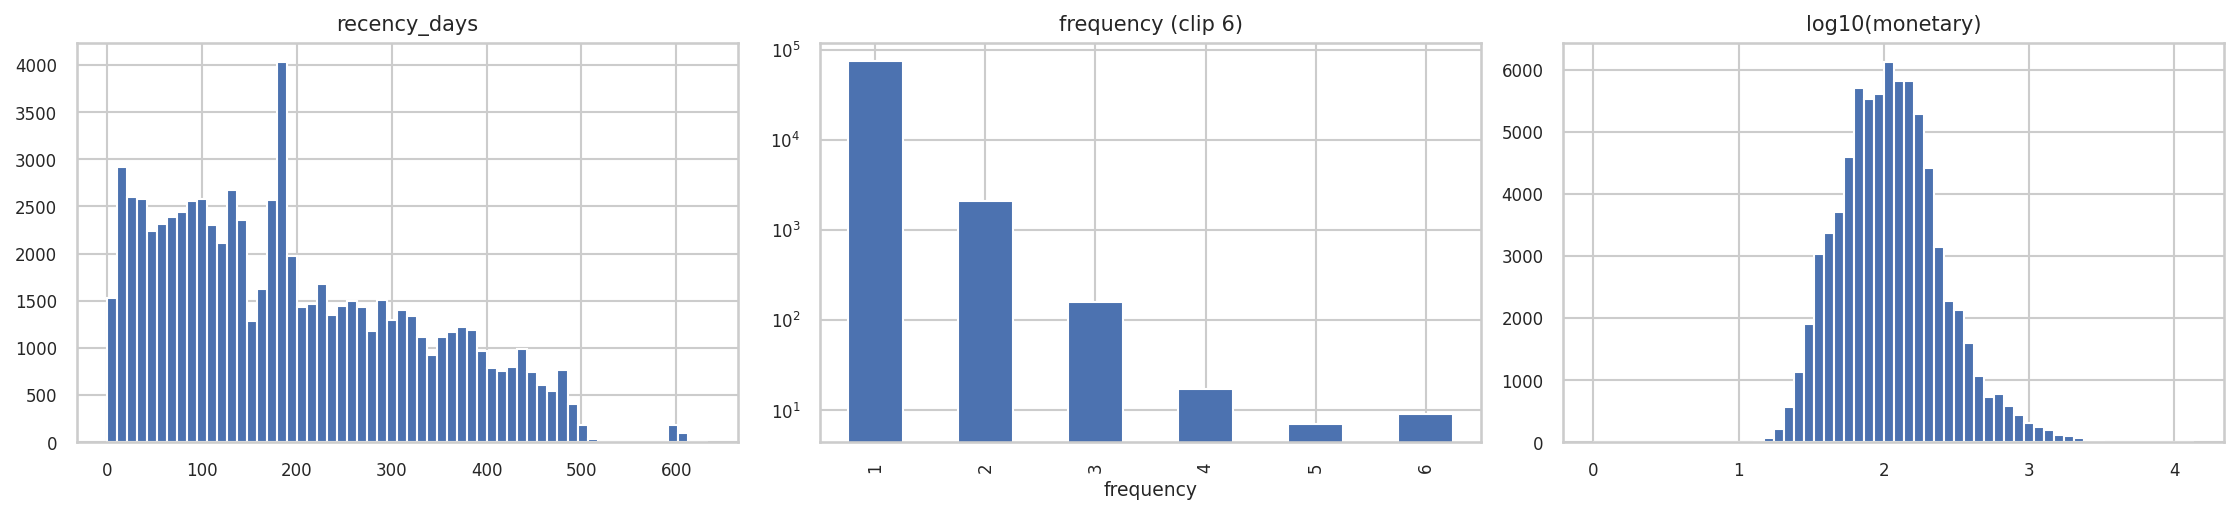

In [9]:
def dominant_by_customer(obs: pd.DataFrame, col: str) -> pd.Series:
    '''Valor modal de `col` por cliente; empates -> alfabeticamente el ultimo.'''
    counts = (obs.dropna(subset=[col])
                 .groupby(["customer_unique_id", col]).size()
                 .reset_index(name="n")
                 .sort_values(["customer_unique_id", "n", col]))
    return counts.groupby("customer_unique_id")[col].last()


def build_master_table(orders_enriched: pd.DataFrame,
                       cutoff_date: pd.Timestamp,
                       horizon_days: int = H) -> pd.DataFrame:
    '''Tabla maestra a nivel cliente, parametrizada por la fecha de corte t.
    Regla anti-fuga: features con pedidos <= t; targets con la ventana (t, t+H].'''
    t = pd.Timestamp(cutoff_date)
    t_end = t + pd.Timedelta(days=horizon_days)

    obs = orders_enriched[orders_enriched.order_purchase_timestamp <= t]
    fut = set(orders_enriched.loc[
        (orders_enriched.order_purchase_timestamp > t)
        & (orders_enriched.order_purchase_timestamp <= t_end),
        "customer_unique_id"])

    g = obs.groupby("customer_unique_id")
    master = pd.DataFrame({
        "recency_days": (t - g.order_purchase_timestamp.max()).dt.days,
        "frequency": g.order_id.nunique(),
        "monetary": g.order_value.sum(),
        "tenure_days": (t - g.order_purchase_timestamp.min()).dt.days,
        "avg_items": g.n_items.mean(),
        "avg_order_value": g.order_value.mean(),
        "avg_freight_value": g.freight_value.mean(),
        "max_installments": g.payment_installments.max(),
        "customer_state": dominant_by_customer(obs, "customer_state"),
        "top_category": dominant_by_customer(obs, "top_category"),
        "payment_type": dominant_by_customer(obs, "payment_type"),
        "avg_review_score": g.review_score.mean(),       # control
        "avg_delay_days": g.delay_days.mean(),           # control
        "pct_late_deliveries": g.is_late.mean(),         # control
        "avg_distance_km": g.distance_km.mean(),
    }).reset_index()

    master["purchased_next_h"] = master.customer_unique_id.isin(fut).astype(int)
    master["is_churn"] = 1 - master.purchased_next_h
    master["is_repeat"] = np.where(master.frequency == 1,
                                   master.purchased_next_h, np.nan)
    master["snapshot_date"] = t
    return master


master_demo = build_master_table(orders_enriched, CUTOFF_DATE_DEMO, H)
print(f"Snapshot demo {CUTOFF_DATE_DEMO:%Y-%m-%d}: {len(master_demo):,} clientes")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
master_demo.recency_days.hist(bins=60, ax=axes[0]); axes[0].set_title("recency_days")
master_demo.frequency.clip(upper=6).value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title("frequency (clip 6)"); axes[1].set_yscale("log")
np.log10(master_demo.monetary.clip(lower=1)).hist(bins=60, ax=axes[2])
axes[2].set_title("log10(monetary)")
plt.tight_layout(); plt.show()

master_demo[["recency_days", "frequency", "monetary", "tenure_days"]].describe().T

### 6. EDA: el retrato del comprador

*¿Quién compra, cuánto, cuándo y desde dónde?* Univariados del pedido, tendencias mensuales,
RFM (ya visto en la tabla maestra), tiempo a la 2ª compra —la evidencia que sostiene `H = 90`—
y cohortes de recompra por mes y por categoría.

Ticket mediano: 105 BRL | entrega mediana: 10 dias | % entregas tardias: 6.8%


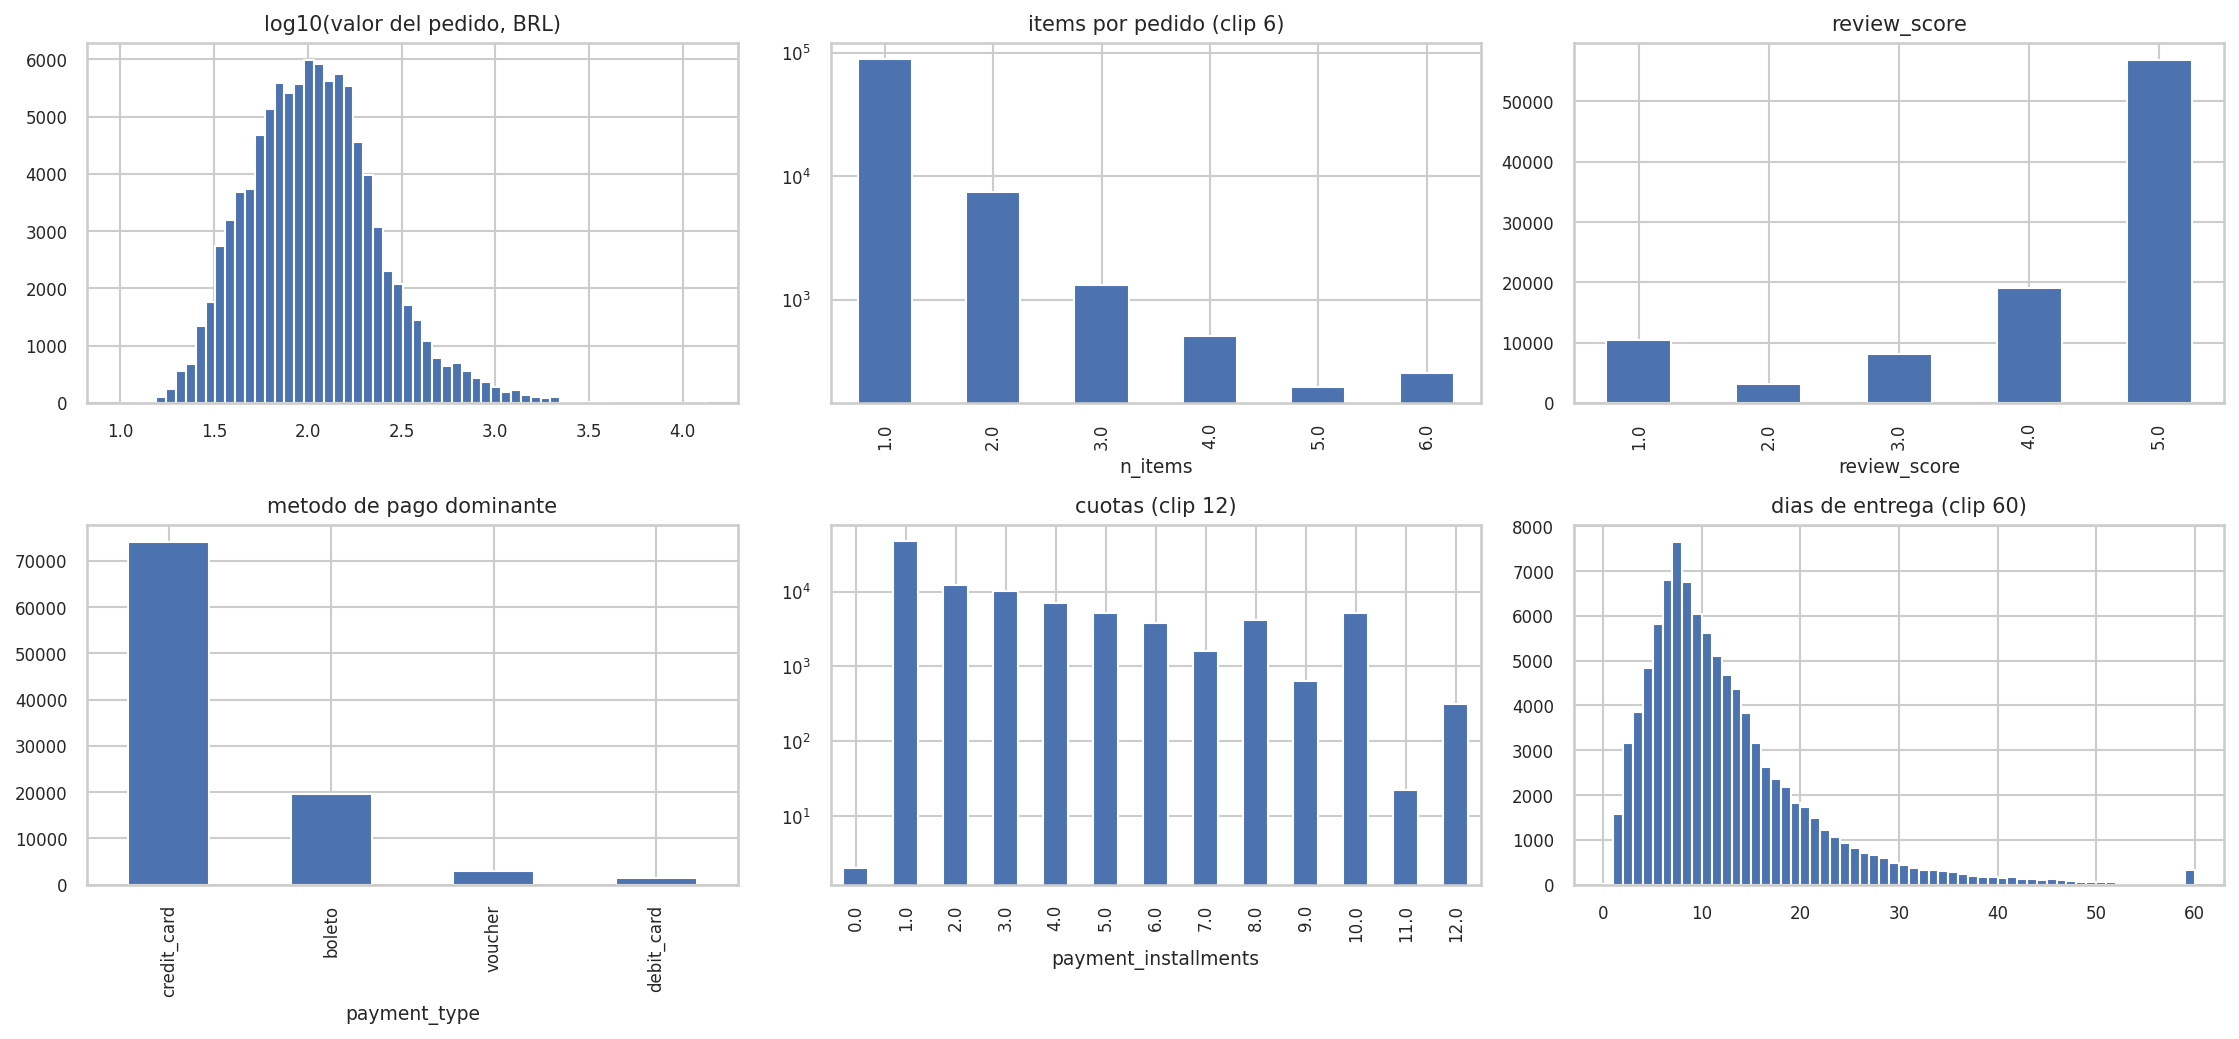

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
np.log10(orders_enriched.order_value.clip(lower=1)).hist(bins=60, ax=axes[0, 0])
axes[0, 0].set_title("log10(valor del pedido, BRL)")
orders_enriched.n_items.clip(upper=6).value_counts().sort_index().plot.bar(ax=axes[0, 1])
axes[0, 1].set_title("items por pedido (clip 6)"); axes[0, 1].set_yscale("log")
orders_enriched.review_score.round().value_counts().sort_index().plot.bar(ax=axes[0, 2])
axes[0, 2].set_title("review_score")
orders_enriched.payment_type.value_counts().plot.bar(ax=axes[1, 0])
axes[1, 0].set_title("metodo de pago dominante")
orders_enriched.payment_installments.clip(upper=12).value_counts().sort_index() \
    .plot.bar(ax=axes[1, 1])
axes[1, 1].set_title("cuotas (clip 12)"); axes[1, 1].set_yscale("log")
orders_enriched.delivery_days.clip(upper=60).hist(bins=60, ax=axes[1, 2])
axes[1, 2].set_title("dias de entrega (clip 60)")
plt.tight_layout(); plt.show()

print(f"Ticket mediano: {orders_enriched.order_value.median():,.0f} BRL | "
      f"entrega mediana: {orders_enriched.delivery_days.median():.0f} dias | "
      f"% entregas tardias: {orders_enriched.is_late.mean():.1%}")

Lectura: crecimiento sostenido en 2017 con pico en Black Friday (nov-2017), meseta en 2018;
los ultimos meses (sep-oct 2018) estan incompletos y no se usan para entrenar ni evaluar.


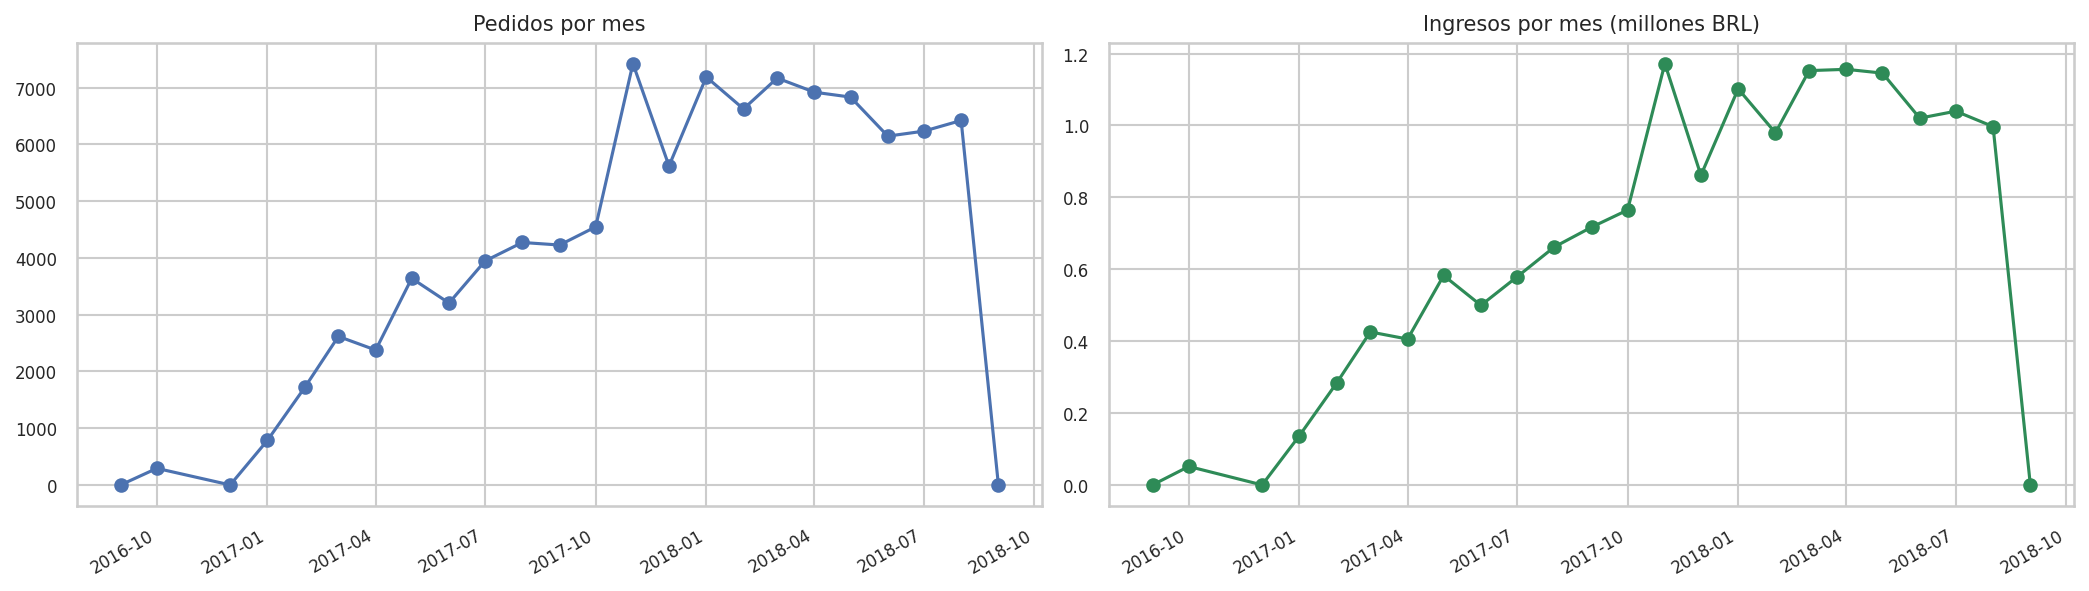

In [11]:
monthly = (orders_enriched
           .assign(month=orders_enriched.order_purchase_timestamp.dt.to_period("M")
                   .dt.to_timestamp())
           .groupby("month").agg(n_pedidos=("order_id", "size"),
                                 ingresos=("order_value", "sum")))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly.n_pedidos.plot(ax=axes[0], marker="o")
axes[0].set_title("Pedidos por mes"); axes[0].set_xlabel("")
monthly.ingresos.div(1e6).plot(ax=axes[1], marker="o", color="seagreen")
axes[1].set_title("Ingresos por mes (millones BRL)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()
print("Lectura: crecimiento sostenido en 2017 con pico en Black Friday (nov-2017), "
      "meseta en 2018;\nlos ultimos meses (sep-oct 2018) estan incompletos y no se usan "
      "para entrenar ni evaluar.")

Concentracion en el sudeste (SP ~42% de los pedidos): customer_region captura esta geografia con 5 niveles en lugar de 27.


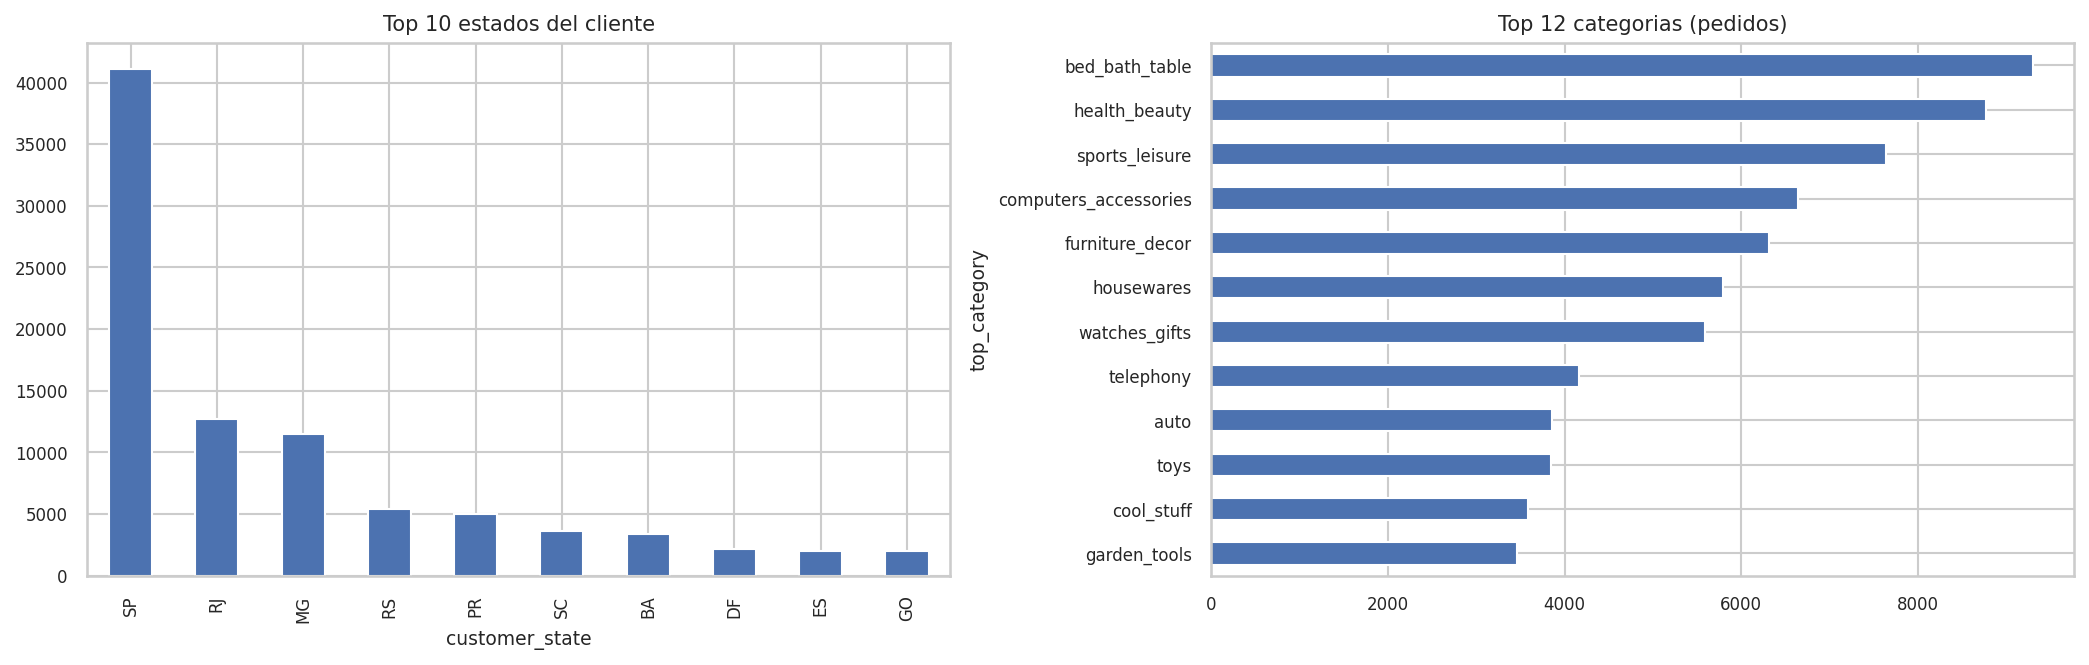

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
orders_enriched.customer_state.value_counts().head(10).plot.bar(ax=axes[0])
axes[0].set_title("Top 10 estados del cliente")
orders_enriched.top_category.value_counts().head(12).plot.barh(ax=axes[1])
axes[1].invert_yaxis(); axes[1].set_title("Top 12 categorias (pedidos)")
plt.tight_layout(); plt.show()
print("Concentracion en el sudeste (SP ~42% de los pedidos): customer_region "
      "captura esta geografia con 5 niveles en lugar de 27.")

Recompradores observados: 2,888
Mediana del tiempo a la 2a compra: 28 dias
  2a compra en <=  30 dias: 51.1% de los que recompran
  2a compra en <=  60 dias: 61.6% de los que recompran
  2a compra en <=  90 dias: 68.4% de los que recompran
  2a compra en <= 120 dias: 74.3% de los que recompran
  2a compra en <= 180 dias: 83.0% de los que recompran


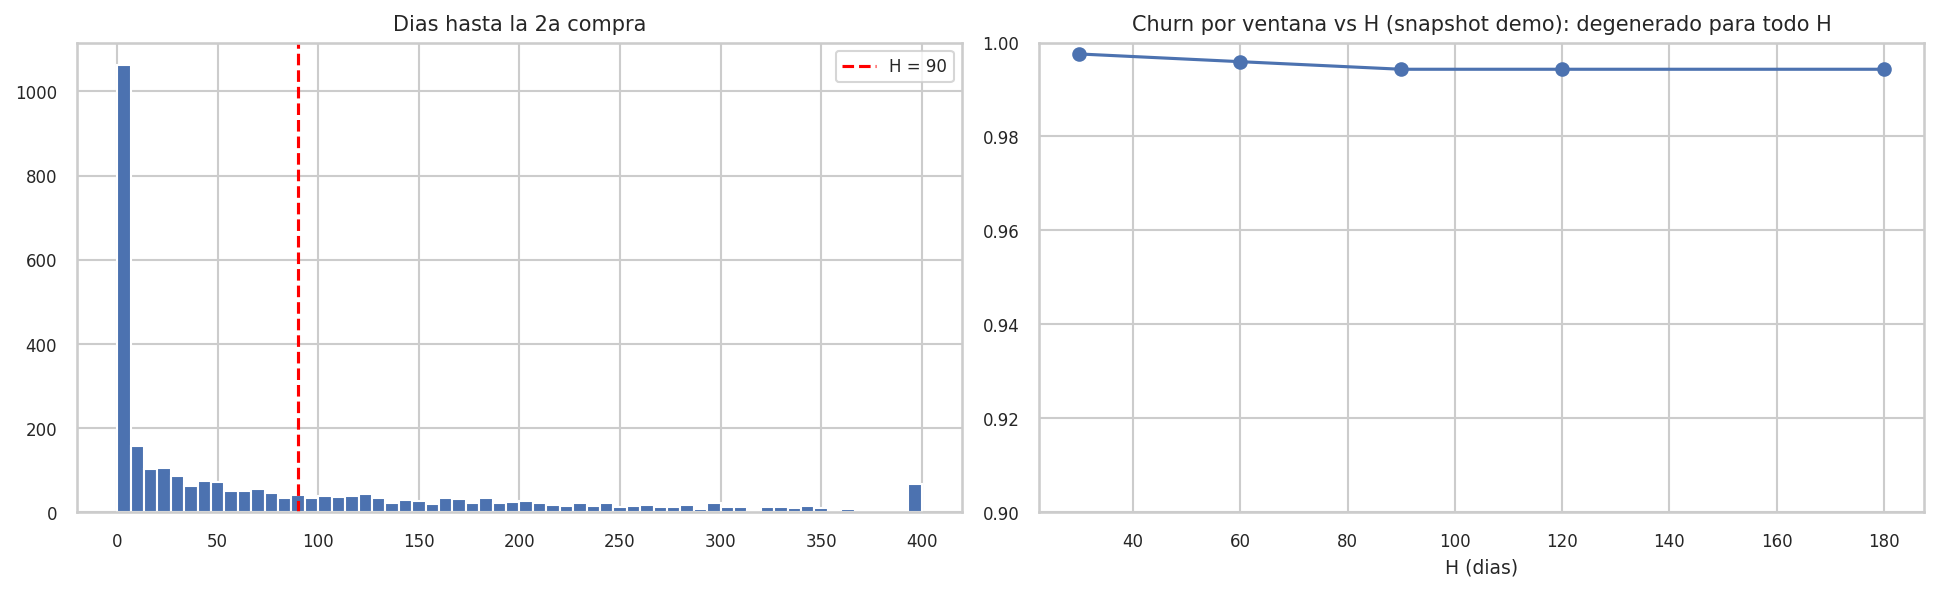

In [13]:
# Tiempo a la 2a compra: la evidencia que sostiene H = 90
po = orders_enriched.sort_values("order_purchase_timestamp").copy()
po["order_rank"] = po.groupby("customer_unique_id").cumcount() + 1

first_order = po[po.order_rank == 1].set_index("customer_unique_id")
second_order = po[po.order_rank == 2].set_index("customer_unique_id")
days_to_second = (second_order.order_purchase_timestamp
                  - first_order.loc[second_order.index,
                                    "order_purchase_timestamp"]).dt.days

data_end = orders_enriched.order_purchase_timestamp.max()
eligible = first_order[first_order.order_purchase_timestamp
                       <= data_end - pd.Timedelta(days=H)].copy()
eligible["is_repeat"] = eligible.index.isin(
    days_to_second[days_to_second <= H].index).astype(int)

print(f"Recompradores observados: {len(days_to_second):,}")
print(f"Mediana del tiempo a la 2a compra: {days_to_second.median():.0f} dias")
for h in [30, 60, 90, 120, 180]:
    print(f"  2a compra en <= {h:>3} dias: {(days_to_second <= h).mean():.1%} "
          "de los que recompran")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
days_to_second.clip(upper=400).hist(bins=60, ax=axes[0])
axes[0].axvline(H, color="red", ls="--", label=f"H = {H}")
axes[0].set_title("Dias hasta la 2a compra"); axes[0].legend()

hs = [30, 60, 90, 120, 180]
churn_by_h = [build_master_table(orders_enriched, CUTOFF_DATE_DEMO, h).is_churn.mean()
              for h in hs]
axes[1].plot(hs, churn_by_h, marker="o")
axes[1].set_ylim(0.9, 1.0); axes[1].set_xlabel("H (dias)")
axes[1].set_title("Churn por ventana vs H (snapshot demo): degenerado para todo H")
plt.tight_layout(); plt.show()

La propension difiere por cohorte y por categoria de entrada: hay senal explotable mas alla del azar.


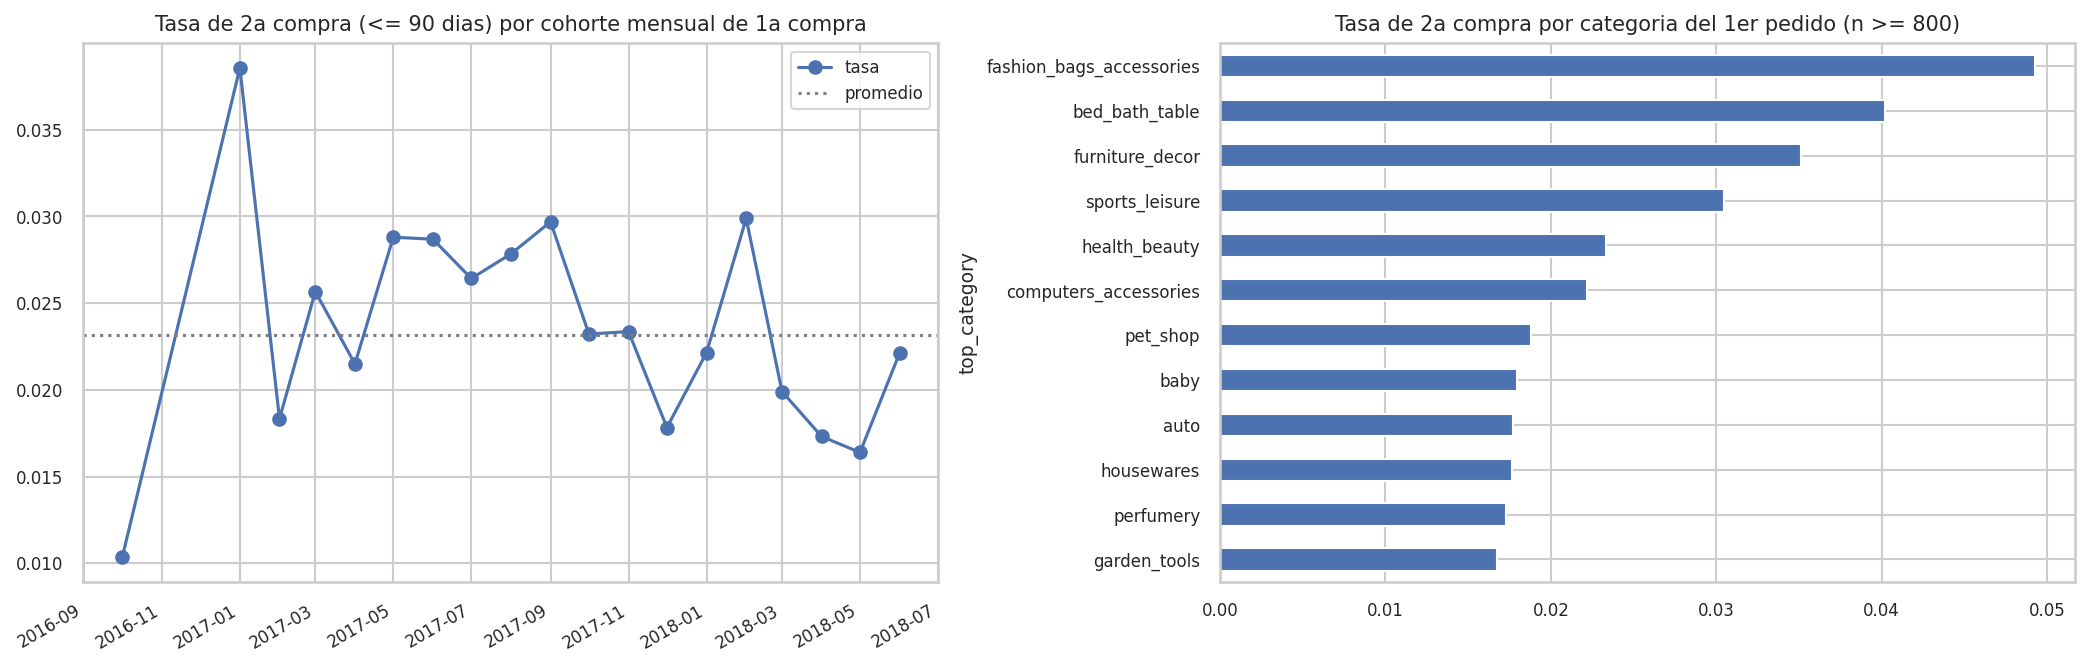

In [14]:
# Cohortes de recompra (definicion pura: 2a compra <= H dias tras la 1a)
eligible["cohort_month"] = (eligible.order_purchase_timestamp
                            .dt.to_period("M").dt.to_timestamp())
coh = (eligible.groupby("cohort_month")
       .agg(n=("is_repeat", "size"), tasa=("is_repeat", "mean")))
coh = coh[coh.n >= 200]

cat_rate = (eligible.groupby("top_category")
            .agg(n=("is_repeat", "size"), tasa=("is_repeat", "mean"))
            .query("n >= 800").sort_values("tasa", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
coh.tasa.plot(ax=axes[0], marker="o")
axes[0].axhline(eligible.is_repeat.mean(), color="gray", ls=":", label="promedio")
axes[0].set_title(f"Tasa de 2a compra (<= {H} dias) por cohorte mensual de 1a compra")
axes[0].legend(); axes[0].set_xlabel("")
cat_rate.head(12).tasa.plot.barh(ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title(f"Tasa de 2a compra por categoria del 1er pedido (n >= 800)")
plt.tight_layout(); plt.show()
print("La propension difiere por cohorte y por categoria de entrada: hay senal "
      "explotable mas alla del azar.")

## Acto IV — El problema bien planteado

> 🟩 **Sprint 1 — Definición del problema y EDA inicial**


### 7. Target y población

*¿Qué predecimos exactamente y sobre quiénes?* Contraste de las dos formulaciones:

| | `is_churn` (por ventana) | `is_repeat` (target del MVP) |
|---|---|---|
| **Definición** | 1 si el cliente NO compra en `(t, t+H]` | 1 si hace su 2ª compra dentro de H días tras la 1ª |
| **Población** | Toda la base activa en `t` | Solo primerizos (`frequency = 1`) en `t` |
| **Distribución** | ~97–99 % positivos: **degenerada** | ~3 % positivos: desbalanceada pero **informativa** |
| **Relación** | `is_churn = 1 − purchased_next_h` | Complemento exacto: predecir recompra ES predecir churn |
| **Rol** | KPI de monitoreo | **Target de modelado** |

En primerizos, *no recomprar dentro de H* **es** el churn: modelar la recompra es modelar el mismo
fenómeno desde la clase minoritaria, que es donde está la información — y es accionable
(campañas de conversión a la 2ª compra).

In [15]:
# A) is_churn por ventana: degenerado en cualquier subpoblacion
m = master_demo
recurrent = m[m.frequency >= 2]
recent = m[m.recency_days <= 180]
recent_recurrent = m[(m.frequency >= 2) & (m.recency_days <= 180)]
print(f"Tasa de is_churn (no comprar en {H} dias) en el snapshot demo:")
print(f"  toda la base         : {m.is_churn.mean():.1%}  (n={len(m):,})")
print(f"  recurrentes          : {recurrent.is_churn.mean():.1%}  (n={len(recurrent):,})")
print(f"  recientes (<=180d)   : {recent.is_churn.mean():.1%}  (n={len(recent):,})")
print(f"  recientes+recurrentes: {recent_recurrent.is_churn.mean():.1%}  "
      f"(n={len(recent_recurrent):,})")
print("-> casi constante: NO sirve como target de un clasificador.\n")

# B) is_repeat (definicion pura sobre poblacion elegible: ventana H observable)
print(f"is_repeat (2a compra en <= {H} dias tras la 1a):")
print(f"  poblacion elegible: {len(eligible):,} clientes primerizos")
print(f"  tasa positiva: {eligible.is_repeat.mean():.2%} "
      "-> desbalanceada pero con varianza: TARGET DEL MVP")

Tasa de is_churn (no comprar en 90 dias) en el snapshot demo:
  toda la base         : 99.4%  (n=76,717)
  recurrentes          : 98.1%  (n=2,300)
  recientes (<=180d)   : 99.3%  (n=39,352)
  recientes+recurrentes: 97.4%  (n=1,287)
-> casi constante: NO sirve como target de un clasificador.

is_repeat (2a compra en <= 90 dias tras la 1a):
  poblacion elegible: 77,568 clientes primerizos
  tasa positiva: 2.32% -> desbalanceada pero con varianza: TARGET DEL MVP


In [16]:
populations = pd.DataFrame([
    {"poblacion": "A) completa (todos los clientes en t)",
     "n": len(m), "tasa_positiva": 1 - m.is_churn.mean(),
     "target": "purchased_next_h", "accionable": "baja (casi todo 0)"},
    {"poblacion": "B) primerizos en t (frequency = 1)",
     "n": int((m.frequency == 1).sum()), "tasa_positiva": m.is_repeat.mean(),
     "target": "is_repeat", "accionable": "ALTA (campanas 2a compra)"},
    {"poblacion": "C) recurrentes en t (frequency >= 2)",
     "n": len(recurrent), "tasa_positiva": 1 - recurrent.is_churn.mean(),
     "target": "purchased_next_h", "accionable": "media (n pequeno)"},
]).set_index("poblacion")
display(populations)
print("Decision: poblacion B con target is_repeat; el desbalance (~3%) se trata con "
      "class_weight='balanced',\nno es degeneracion. Metricas: AUC (principal), "
      "PR-AUC y recall de la clase positiva.")

,n,tasa_positiva,target,accionable
poblacion,,,,
A) completa (todos los clientes en t),76717,0.006,purchased_next_h,baja (casi todo 0)
B) primerizos en t (frequency = 1),74417,0.005,is_repeat,ALTA (campanas 2a compra)
C) recurrentes en t (frequency >= 2),2300,0.019,purchased_next_h,media (n pequeno)


Decision: poblacion B con target is_repeat; el desbalance (~3%) se trata con class_weight='balanced',
no es degeneracion. Metricas: AUC (principal), PR-AUC y recall de la clase positiva.


### 8. Partición temporal

*¿Cómo evitamos entrenar con el futuro?* De las tres familias de partición, solo una es válida aquí:

1. **Holdout aleatorio** — mezcla filas al azar: *inválido* (clientes de 2018 entrenarían un modelo
   que se evalúa en 2017: fuga temporal).
2. **K-fold / estratificado** — robusto en datos i.i.d., pero hereda la misma fuga temporal.
3. **Out-of-time (la usada)** — particionar por `snapshot_date`: entrenar con el pasado, predecir el futuro.

**Esquema:** snapshots a fin de mes; en cada uno se materializa la tabla maestra, se filtran los
**primerizos** y cada cliente entra **una sola vez** (en su primer snapshot tras la 1ª compra, evitando
filas casi duplicadas entre splits). La definición **operacional** del target es la del job de
producción: 2ª compra dentro de `(t, t+H]` con `t` = primer fin de mes tras la 1ª compra.

| Split | Snapshots | Uso |
|---|---|---|
| `train` | 2017-01 .. 2017-12 | Ajuste del modelo y selección de variables |
| `validation` | 2018-01 .. 2018-03 | Comparación de modelos y decisiones (uso repetido) |
| `backtest` | 2018-04 .. fin | Evaluación final de **uso único** |

**Regla adicional:** la ventana de resultado `(t, t+H]` debe caer **dentro del rango de datos**:
el último snapshot se calcula de modo que `t + H ≤` fecha máxima observada (el job de producción
usa `2018-07-31` aceptando ~12 días de truncamiento; aquí aplicamos la regla estricta).

In [17]:
# Panel de snapshots mensuales (espejo del job de produccion en Databricks)
try:
    all_cutoffs = pd.date_range(SNAPSHOT_START, data_end, freq="ME")
except ValueError:                       # pandas < 2.2
    all_cutoffs = pd.date_range(SNAPSHOT_START, data_end, freq="M")
cutoffs = all_cutoffs[all_cutoffs + pd.Timedelta(days=H) <= data_end]
SNAPSHOT_END = cutoffs[-1]
print(f"Fin de datos: {data_end:%Y-%m-%d} -> {len(cutoffs)} snapshots: "
      f"{cutoffs[0]:%Y-%m-%d} .. {SNAPSHOT_END:%Y-%m-%d} (t + {H}d dentro del rango)")

snapshots = []
for t in cutoffs:
    snap = build_master_table(orders_enriched, t, H)
    snapshots.append(snap[snap.frequency == 1])      # poblacion del MVP: primerizos

panel = pd.concat(snapshots, ignore_index=True)
panel = (panel.sort_values("snapshot_date")
              .drop_duplicates("customer_unique_id", keep="first")   # 1 cliente = 1 fila
              .reset_index(drop=True))
panel["is_repeat"] = panel.is_repeat.astype(int)

# primer pedido del cliente -> candidatas de ingenieria (visibles al comprar)
first_order_map = (orders_enriched.sort_values("order_purchase_timestamp")
                   .drop_duplicates("customer_unique_id", keep="first")
                   [["customer_unique_id", "order_id", "order_purchase_timestamp"]]
                   .rename(columns={"order_id": "first_order_id",
                                    "order_purchase_timestamp": "first_purchase_ts"}))
panel = (panel.merge(first_order_map, on="customer_unique_id", how="left")
              .merge(engineered.rename(columns={"order_id": "first_order_id"}),
                     on="first_order_id", how="left"))

panel["split"] = np.select(
    [panel.snapshot_date <= "2017-12-31", panel.snapshot_date <= "2018-03-31"],
    ["train", "validation"], default="backtest")

print(f"Panel: {len(panel):,} clientes primerizos unicos | "
      f"tasa global de recompra: {panel.is_repeat.mean():.2%}")

Fin de datos: 2018-09-03 -> 17 snapshots: 2017-01-31 .. 2018-05-31 (t + 90d dentro del rango)
Panel: 75,630 clientes primerizos unicos | tasa global de recompra: 1.01%


Nota: los clientes de 2016 entran en el primer snapshot (2017-01-31), dentro de train.


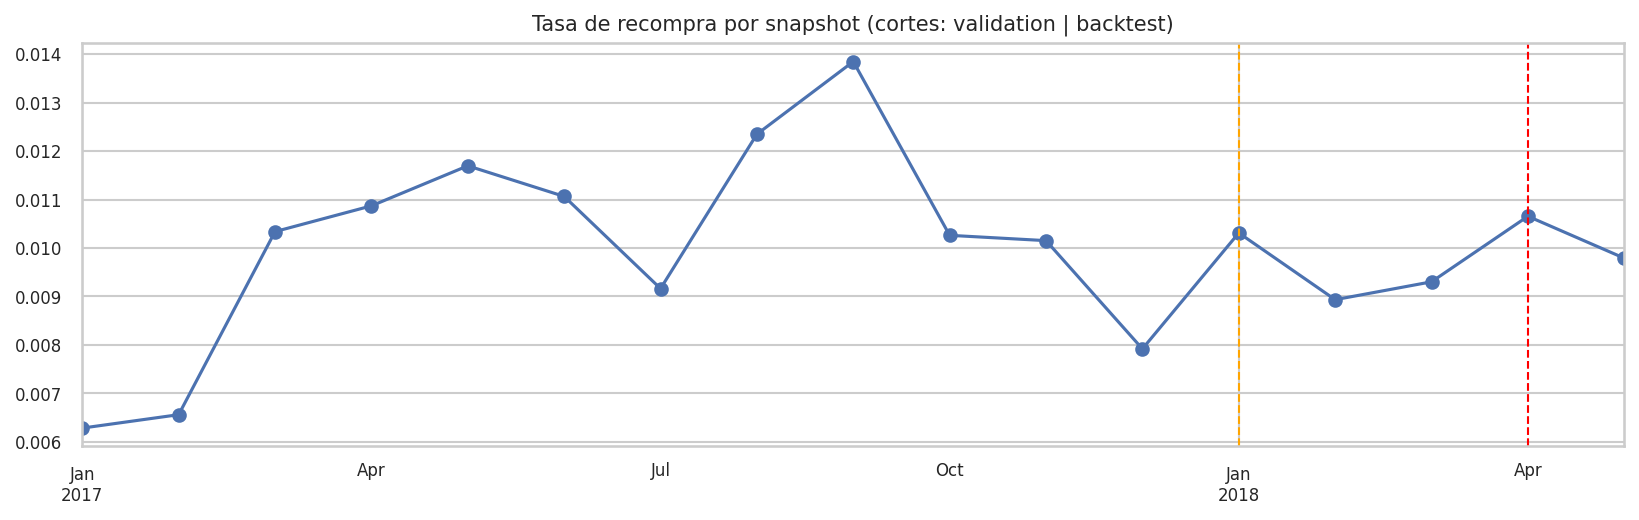

In [18]:
split_summary = (panel.groupby("split")
                 .agg(n=("is_repeat", "size"), positivos=("is_repeat", "sum"),
                      tasa_recompra=("is_repeat", "mean"),
                      snapshot_min=("snapshot_date", "min"),
                      snapshot_max=("snapshot_date", "max"))
                 .loc[["train", "validation", "backtest"]])
display(split_summary)

drift = (panel.groupby("snapshot_date")
         .agg(n=("is_repeat", "size"), tasa=("is_repeat", "mean")))
fig, ax = plt.subplots(figsize=(11, 3.5))
drift.tasa.plot(ax=ax, marker="o")
for b, c in [("2018-01-01", "orange"), ("2018-04-01", "red")]:
    ax.axvline(pd.Timestamp(b), color=c, ls="--", lw=1)
ax.set_title("Tasa de recompra por snapshot (cortes: validation | backtest)")
ax.set_xlabel("")
plt.tight_layout(); plt.show()
print("Nota: los clientes de 2016 entran en el primer snapshot (2017-01-31), "
      "dentro de train.")

## Acto V — El embudo, el modelo y la decisión

> 🟨 **Sprint 2 — Ingeniería de datos y pipeline** · §9 selección de variables · §13–14 métricas con pipeline · §18–19 simulación mensual.
>
> 🟧 **Sprint 3 — Hiperparametrización y modelo final** · §10–12 modelos y backtest · §11.b tuning + CV · §12.b feature importance · §15–17 artefacto `.pkl`.


### 9. Embudo de selección de variables

*¿Qué variables son útiles y cuáles descartamos?* El embudo va de filtros baratos a métodos
costosos; **ninguna técnica decide sola**, la decisión final es por consenso de rangos. Se ejecuta
recién aquí —y no junto al casting del Acto II— porque necesita el target y la partición ya
definidos: la utilidad se mide contra `is_repeat` en **validación** out-of-time, sin tocar el backtest.

1. **Filtro:** varianza casi nula → Mutual Information y ANOVA-F (numéricas) · Cramér's V (categóricas)
   → correlación de pares `|r| > 0,9` (se conserva la de mayor MI).
2. **Multicolinealidad:** VIF iterativo, descartando mientras `VIF > 10`.
3. **Embebidos:** regresión logística **L1** (coeficientes a cero) · importancia de **Random Forest** ·
   **permutation importance** (caída de AUC en validación, la más confiable).
4. **Wrapper:** **RFECV** con validación cruzada sobre las supervivientes (*Boruta se omite para no
   añadir dependencias externas*).
5. **Consenso:** promedio de rangos (MI, |coef L1|, RF, permutación) → veredicto:
   **seleccionadas / control / descartadas**. Las señales post-compra (`avg_review_score`,
   `avg_delay_days`, `pct_late_deliveries`) quedan como **control** por diseño: no compiten.

Varianza casi nula: ['frequency'] -> fuera (frequency es constante=1 en primerizos)
Par |r|>0.9: recency_days ~ tenure_days (r=+1.000) -> fuera tenure_days
Par |r|>0.9: monetary ~ avg_order_value (r=+1.000) -> fuera avg_order_value
Par |r|>0.9: monetary ~ avg_item_price (r=+0.910) -> fuera monetary


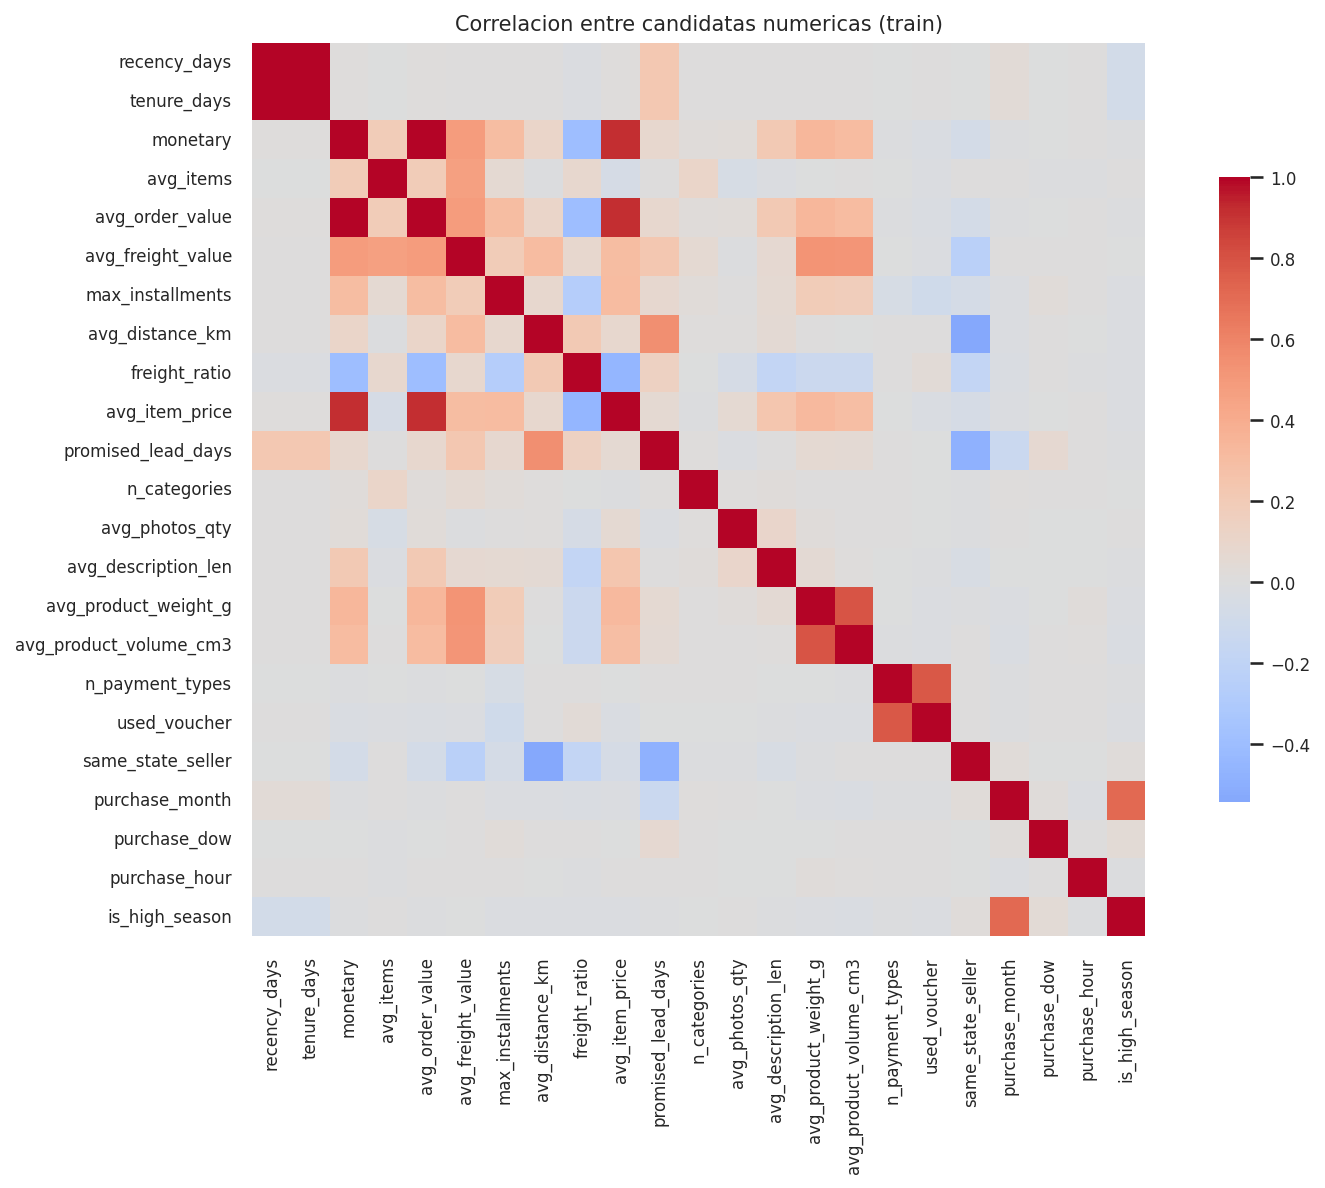

In [19]:
from sklearn.feature_selection import f_classif, mutual_info_classif

train = panel[panel.split == "train"]
valid = panel[panel.split == "validation"]
y_tr, y_va = train[TARGET], valid[TARGET]

num_candidates = [c for c in DIRECT_NUM + ENGINEERED_NUM]
verdict, drop_reason = {}, {}

# --- 1a) varianza casi nula ---
nzv = [c for c in num_candidates if train[c].nunique(dropna=True) <= 1]
for c in nzv:
    verdict[c] = "descartada (varianza nula)"
print(f"Varianza casi nula: {nzv} -> fuera (frequency es constante=1 en primerizos)")
num_alive = [c for c in num_candidates if c not in nzv]

# --- 1b) Mutual Information (submuestra para acelerar) y ANOVA-F en train ---
Xn = train[num_alive].fillna(train[num_alive].median())
rs = np.random.RandomState(RANDOM_STATE)
idx = rs.choice(len(Xn), size=min(25_000, len(Xn)), replace=False)
mi_num = pd.Series(mutual_info_classif(Xn.iloc[idx], y_tr.iloc[idx],
                                       random_state=RANDOM_STATE), index=num_alive)
f_stat, _ = f_classif(Xn, y_tr)
f_num = pd.Series(f_stat, index=num_alive)

# --- 1c) correlacion de pares |r| > 0.9: se conserva la de mayor MI ---
corr = Xn.corr()
to_drop = set()
for i, a in enumerate(num_alive):
    for b in num_alive[i + 1:]:
        if a in to_drop or b in to_drop:
            continue
        if abs(corr.loc[a, b]) > 0.9:
            loser = a if mi_num[a] < mi_num[b] else b
            winner = b if loser == a else a
            to_drop.add(loser)
            verdict[loser] = f"descartada (|r|>0.9 con {winner})"
            print(f"Par |r|>0.9: {a} ~ {b} (r={corr.loc[a, b]:+.3f}) -> fuera {loser}")
num_alive = [c for c in num_alive if c not in to_drop]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink": 0.7}, square=True)
ax.set_title("Correlacion entre candidatas numericas (train)")
plt.tight_layout(); plt.show()

In [20]:
# --- 2) VIF iterativo: descartar mientras VIF > 10 ---
def compute_vif(X: pd.DataFrame) -> pd.Series:
    '''VIF = 1 / (1 - R2) al regresar cada columna sobre las demas (estandarizado).'''
    Z = ((X - X.mean()) / X.std(ddof=0)).fillna(0.0).to_numpy()
    out = {}
    for i, col in enumerate(X.columns):
        y_i = Z[:, i]
        X_o = np.delete(Z, i, axis=1)
        beta, *_ = np.linalg.lstsq(X_o, y_i, rcond=None)
        resid = y_i - X_o @ beta
        r2 = 1 - resid.var() / y_i.var() if y_i.var() > 0 else 0.0
        out[col] = np.inf if r2 >= 1 else 1.0 / max(1e-12, 1.0 - r2)
    return pd.Series(out).sort_values(ascending=False)

vif_alive = list(num_alive)
while True:
    vifs = compute_vif(Xn[vif_alive])
    if vifs.iloc[0] <= 10:
        break
    worst = vifs.index[0]
    vif_alive.remove(worst)
    verdict[worst] = f"descartada (VIF={vifs.iloc[0]:.1f})"
    print(f"VIF>10: fuera {worst} (VIF={vifs.iloc[0]:.1f})")

num_alive = vif_alive
print("\nVIF final de las supervivientes:")
display(compute_vif(Xn[num_alive]).to_frame("VIF").T)


VIF final de las supervivientes:


,avg_product_weight_g,avg_freight_value,avg_product_volume_cm3,used_voucher,n_payment_types,purchase_month,is_high_season,avg_distance_km,promised_lead_days,avg_items,avg_item_price,same_state_seller,freight_ratio,max_installments,recency_days,avg_description_len,avg_photos_qty,n_categories,purchase_dow,purchase_hour
VIF,2.978,2.956,2.916,2.505,2.487,2.235,2.180,1.925,1.830,1.664,1.630,1.579,1.515,1.189,1.142,1.086,1.016,1.015,1.010,1.001


In [21]:
# --- 3) categoricas: Cramer's V contra el target + MI discreta ---
from scipy.stats import chi2_contingency

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    tab = pd.crosstab(x.fillna("missing"), y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    return float(np.sqrt(chi2 / (n * (min(tab.shape) - 1))))

cat_alive = list(CAT_CANDIDATES)
v_cat = pd.Series({c: cramers_v(train[c], y_tr) for c in cat_alive})

codes = pd.DataFrame({c: train[c].astype("category").cat.codes for c in cat_alive})
mi_cat = pd.Series(mutual_info_classif(codes.iloc[idx], y_tr.iloc[idx],
                                       discrete_features=True,
                                       random_state=RANDOM_STATE), index=cat_alive)
display(pd.DataFrame({"cramers_v": v_cat, "MI": mi_cat})
        .sort_values("cramers_v", ascending=False))

# customer_state y customer_region codifican lo mismo: gana la de mayor Cramer's V
pair = ["customer_state", "customer_region"]
loser = min(pair, key=lambda c: v_cat[c])
winner = max(pair, key=lambda c: v_cat[c])
cat_alive.remove(loser)
verdict[loser] = f"descartada (redundante con {winner})"
print(f"Redundancia geografica: se conserva {winner}, fuera {loser}")

,cramers_v,MI
top_category,0.042,0.001
customer_state,0.024,0.000
customer_region,0.010,0.000
payment_type,0.010,0.000


Redundancia geografica: se conserva customer_state, fuera customer_region


In [22]:
# --- 4) embebidos: L1, Random Forest y permutation importance (validacion) ---
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor(num_cols, cat_cols) -> ColumnTransformer:
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   min_frequency=200))]), cat_cols),
    ])

def aggregate_to_columns(names, values, num_cols, cat_cols) -> pd.Series:
    '''Suma |valor| de cada columna transformada hacia su columna original.'''
    agg = dict.fromkeys(list(num_cols) + list(cat_cols), 0.0)
    for n, v in zip(names, values):
        base = n.split("__", 1)[1]
        if base in agg:
            agg[base] += abs(float(v))
            continue
        for c in cat_cols:
            if base.startswith(c + "_"):
                agg[c] += abs(float(v))
                break
    return pd.Series(agg)

X_tr_raw = train[num_alive + cat_alive]
X_va_raw = valid[num_alive + cat_alive]

prep = make_preprocessor(num_alive, cat_alive)
X_tr_t = prep.fit_transform(X_tr_raw, y_tr)
feat_names = prep.get_feature_names_out()

# L1: la regularizacion lleva a cero los coeficientes irrelevantes
l1 = LogisticRegression(penalty="l1", C=0.1, solver="liblinear",
                        class_weight="balanced", max_iter=2000,
                        random_state=RANDOM_STATE).fit(X_tr_t, y_tr)
l1_imp = aggregate_to_columns(feat_names, l1.coef_[0], num_alive, cat_alive)

# Random Forest: reduccion de impureza (barata pero sesgada a alta cardinalidad)
rf_pipe = Pipeline([("prep", make_preprocessor(num_alive, cat_alive)),
                    ("clf", RandomForestClassifier(
                        n_estimators=300, min_samples_leaf=20, n_jobs=-1,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE))]).fit(X_tr_raw, y_tr)
rf_imp = aggregate_to_columns(rf_pipe[:-1].get_feature_names_out(),
                              rf_pipe[-1].feature_importances_,
                              num_alive, cat_alive)

# Permutation importance: caida de AUC en VALIDACION al barajar cada columna
perm = permutation_importance(rf_pipe, X_va_raw, y_va, scoring="roc_auc",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_va_raw.columns)

embedded = pd.DataFrame({"L1_|coef|": l1_imp, "RF_importance": rf_imp,
                         "perm_AUC_drop": perm_imp}).sort_values(
    "perm_AUC_drop", ascending=False)
display(embedded.round(4))

,L1_|coef|,RF_importance,perm_AUC_drop
freight_ratio,0.017,0.078,0.019
top_category,7.581,0.074,0.016
avg_photos_qty,0.177,0.032,0.013
promised_lead_days,0.135,0.061,0.013
recency_days,0.086,0.062,0.010
max_installments,0.115,0.033,0.010
avg_item_price,0.154,0.070,0.009
avg_product_volume_cm3,0.022,0.075,0.007
avg_distance_km,0.026,0.078,0.006
payment_type,0.942,0.018,0.005


Columnas originales con soporte RFECV: ['recency_days', 'avg_items', 'avg_freight_value', 'max_installments', 'avg_distance_km', 'avg_item_price', 'promised_lead_days', 'n_categories', 'avg_photos_qty', 'avg_description_len', 'n_payment_types', 'used_voucher', 'same_state_seller', 'purchase_month', 'purchase_hour', 'is_high_season', 'customer_state', 'top_category', 'payment_type']


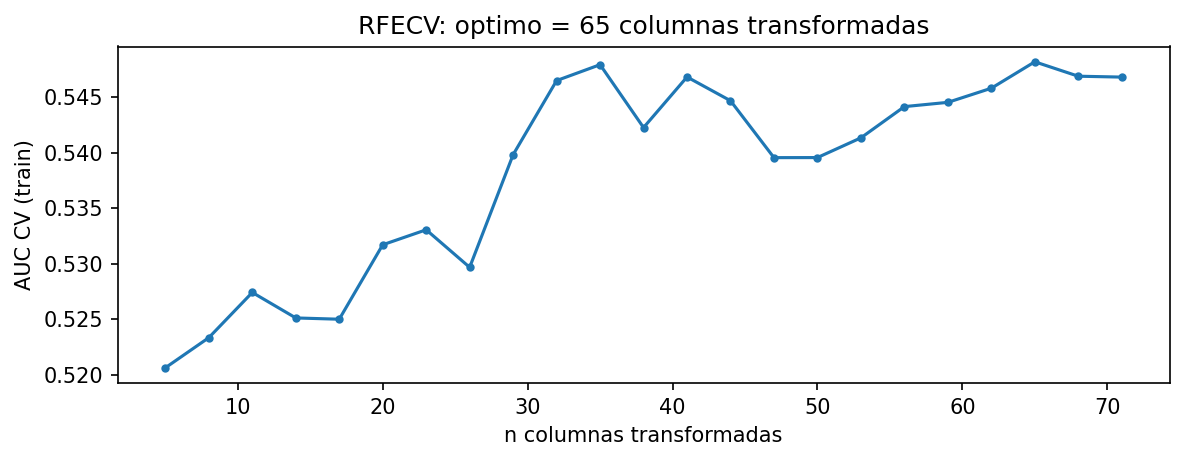

In [23]:
# --- 5) wrapper: RFECV sobre las supervivientes ---
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rfecv = RFECV(LogisticRegression(class_weight="balanced", max_iter=2000,
                                 random_state=RANDOM_STATE),
              step=3, min_features_to_select=5, scoring="roc_auc",
              cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
              n_jobs=-1).fit(X_tr_t, y_tr)

rfecv_support = pd.Series(False, index=num_alive + cat_alive)
for n, s in zip(feat_names, rfecv.support_):
    base = n.split("__", 1)[1]
    if base in rfecv_support.index:
        if s: rfecv_support[base] = True
        continue
    for c in cat_alive:
        if base.startswith(c + "_") and s:
            rfecv_support[c] = True
            break

scores = rfecv.cv_results_["mean_test_score"]
xs = rfecv.cv_results_.get("n_features", np.arange(len(scores)))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(xs, scores, marker="o", ms=3)
ax.set_xlabel("n columnas transformadas"); ax.set_ylabel("AUC CV (train)")
ax.set_title(f"RFECV: optimo = {rfecv.n_features_} columnas transformadas")
plt.tight_layout(); plt.show()
print("Columnas originales con soporte RFECV:",
      list(rfecv_support[rfecv_support].index))

SELECCIONADAS (13): ['avg_item_price', 'avg_photos_qty', 'promised_lead_days', 'max_installments', 'recency_days', 'avg_freight_value', 'n_categories', 'avg_items', 'avg_distance_km', 'n_payment_types', 'used_voucher', 'top_category', 'payment_type']


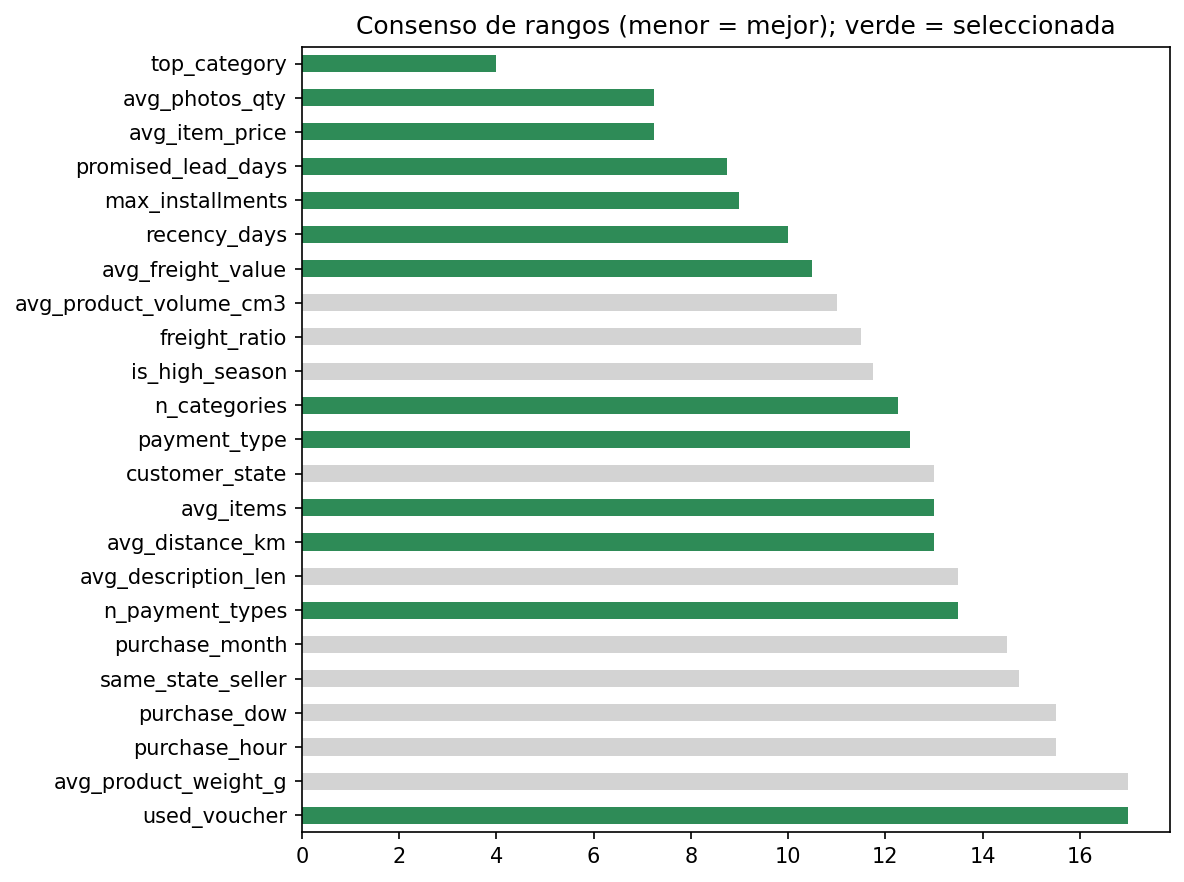

In [24]:
# --- 6) consenso de rangos y veredicto final ---
mi_all = pd.concat([mi_num[num_alive], mi_cat[cat_alive]])
funnel = pd.DataFrame({"MI": mi_all, "L1_|coef|": l1_imp,
                       "RF_importance": rf_imp, "perm_AUC_drop": perm_imp})
ranks = funnel.rank(ascending=False)
funnel["rank_consenso"] = ranks.mean(axis=1)
funnel["RFECV"] = rfecv_support
funnel = funnel.sort_values("rank_consenso")

# Seleccionada = soporte RFECV y permutation importance positiva
selected = [c for c in funnel.index
            if funnel.loc[c, "RFECV"] and funnel.loc[c, "perm_AUC_drop"] > 0]
if len(selected) < 6:                       # red de seguridad: top-8 del consenso
    selected = funnel.index[:8].tolist()
for c in funnel.index:
    verdict[c] = "seleccionada" if c in selected else "descartada (consenso)"
for c in CONTROL_NUM:
    verdict[c] = "control (post-compra)"

SELECTED_NUM = [c for c in selected if c in num_alive]
SELECTED_CAT = [c for c in selected if c in cat_alive]
FEATURES = SELECTED_NUM + SELECTED_CAT

verdict_df = (pd.DataFrame.from_dict(verdict, orient="index", columns=["veredicto"])
              .join(funnel.drop(columns="RFECV"))
              .sort_values(["veredicto", "rank_consenso"]))
display(verdict_df.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
funnel.rank_consenso.sort_values(ascending=False).plot.barh(
    ax=ax, color=["seagreen" if c in selected else "lightgray"
                  for c in funnel.rank_consenso.sort_values(ascending=False).index])
ax.set_title("Consenso de rangos (menor = mejor); verde = seleccionada")
plt.tight_layout(); plt.show()

print(f"SELECCIONADAS ({len(FEATURES)}): {FEATURES}")

### 9.b Variables descartadas y su motivo (por tipo)

*¿Qué quedó fuera y por qué?* El embudo clasificó las **31 candidatas** en **13 seleccionadas**, **3 de control** y **15 descartadas**. Los descartes se agrupan por tipo de motivo (la tabla viva es `verdict_df`, arriba):

| Tipo de motivo | Variables | Por qué |
|---|---|---|
| **Varianza nula** (calidad de dato) | `frequency` | Constante = 1 en primerizos: sin varianza, no informa. |
| **Redundancia** (correlación \|r\|>0,9) | `tenure_days` (≡ `recency_days`), `avg_order_value` (≡ `monetary`), `monetary` (r=0,91 con `avg_item_price`) | Información ya contenida en otra variable; se conserva una de cada par. |
| **Redundancia geográfica** | `customer_region` | Redundante con `customer_state`, que ya captura la ubicación. |
| **Sin señal** (no superan consenso/RFECV; permutación ≤ 0) | `freight_ratio`, `avg_product_weight_g`, `avg_product_volume_cm3`, `purchase_dow`, `purchase_month`, `purchase_hour`, `is_high_season`, `avg_description_len`, `same_state_seller`, `customer_state` | Limpias y disponibles, pero su aporte predictivo a la recompra no es significativo. |

> Las variables de **control** (`avg_review_score`, `avg_delay_days`, `pct_late_deliveries`) no se descartan ni se usan como features: son señales **post-compra** del 1er pedido, reservadas para diagnóstico (usarlas como features sería fuga).

**Nota metodológica:** "no aporta al modelo" es un veredicto de la **selección de variables** (este embudo), no de la limpieza. La limpieza solo descarta por *calidad de dato* (p. ej. `frequency`, sin varianza); el resto se descarta por redundancia o por falta de señal predictiva.


### 10. Entrenamiento de modelos candidatos

*¿Qué familias compiten y en qué condiciones?* Todas sobre las variables **seleccionadas** por el
embudo, con el mismo preprocesamiento (mediana + escala para numéricas; moda + one-hot con
`min_frequency` para categóricas) y manejo del desbalance vía `class_weight='balanced'`.

| Modelo | Fortalezas | Debilidades |
|---|---|---|
| DummyClassifier | Define el piso; gratis | No es un modelo real |
| Regresión logística balanceada | Interpretable, rápida, ideal para MVP | Solo fronteras lineales |
| Random Forest | No lineal, tolera outliers y mezclas | Menos interpretable, más pesado |
| HistGradientBoosting | Estado del arte en tabular (familia GB nativa de sklearn, sin dependencias extra) | Hiperparámetros sensibles |

*SVM/KNN se descartan por escala (~90k filas) y los modelos de lifetime (BG/NBD) por el 97 % de
primerizos (requieren historial de repetición).*

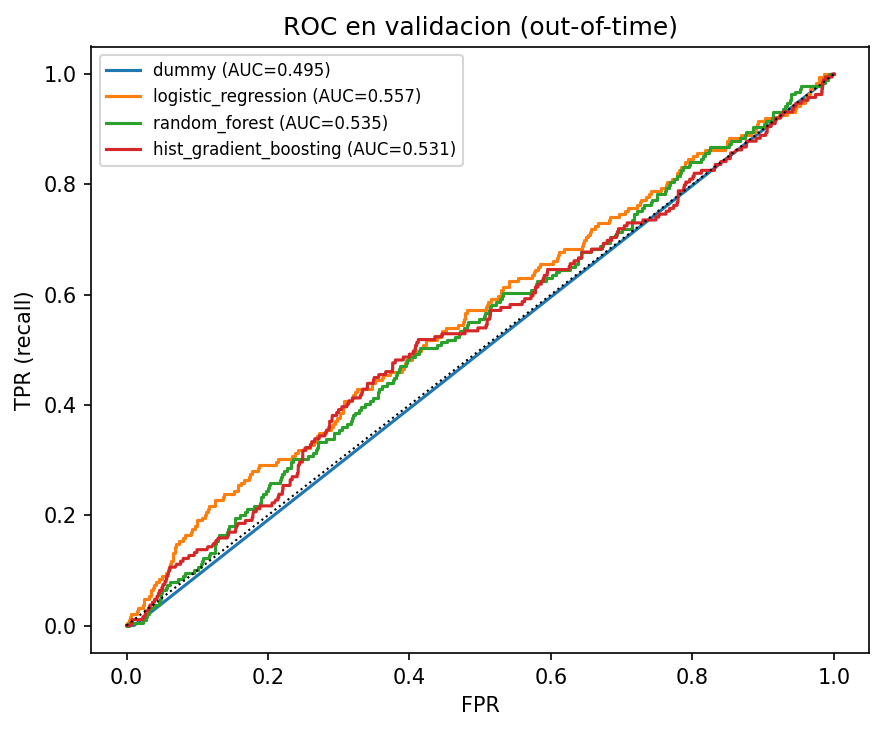

In [25]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (average_precision_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)

def evaluate(y_true, proba, threshold=0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    return {"AUC": roc_auc_score(y_true, proba),
            "PR_AUC": average_precision_score(y_true, proba),
            "recall": recall_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred)}

MODELS = {
    "dummy": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "logistic_regression": LogisticRegression(class_weight="balanced", max_iter=2000,
                                              random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                            class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE),
}

X_tr, X_va = train[FEATURES], valid[FEATURES]
fitted, rows = {}, {}
for name, clf in MODELS.items():
    pipe = Pipeline([("prep", make_preprocessor(SELECTED_NUM, SELECTED_CAT)),
                     ("clf", clf)])
    pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
    rows[name] = evaluate(y_va, pipe.predict_proba(X_va)[:, 1])

model_comparison = pd.DataFrame(rows).T.sort_values("AUC", ascending=False)
display(model_comparison.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted.items():
    fpr, tpr, _ = roc_curve(y_va, pipe.predict_proba(X_va)[:, 1])
    ax.plot(fpr, tpr, label=f"{name} (AUC={rows[name]['AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR (recall)")
ax.set_title("ROC en validacion (out-of-time)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 11. Elección del mejor modelo

*¿Cuál gana y por qué?* Criterios del proyecto: **AUC** como métrica principal (ordenamiento robusto
al desbalance), **recall de la clase positiva**, **estabilidad** entre snapshots de validación e
**interpretabilidad**. Regla de decisión: gana el mayor AUC; si la logística queda a menos de
0,01 de AUC del líder, se prefiere por interpretabilidad (MVP).

In [26]:
stab = {}
for name, pipe in fitted.items():
    if name == "dummy":
        continue
    stab[name] = {str(snap.date()): roc_auc_score(
        grp[TARGET], pipe.predict_proba(grp[FEATURES])[:, 1])
        for snap, grp in valid.groupby("snapshot_date")}
stability = pd.DataFrame(stab)
stability.loc["std"] = stability.std()
display(stability.round(4))

best_by_auc = model_comparison.AUC.idxmax()
auc_lr = model_comparison.loc["logistic_regression", "AUC"]
if best_by_auc != "logistic_regression" \
        and auc_lr >= model_comparison.AUC.max() - 0.01:
    CHOSEN = "logistic_regression"
    print(f"Mejor AUC: {best_by_auc} ({model_comparison.AUC.max():.4f}), pero la "
          f"logistica ({auc_lr:.4f}) queda a <0.01:\nELEGIDA logistic_regression "
          "por interpretabilidad a igual rendimiento.")
else:
    CHOSEN = best_by_auc
    print(f"ELEGIDO: {CHOSEN} (AUC validacion = "
          f"{model_comparison.loc[CHOSEN, 'AUC']:.4f}, recall = "
          f"{model_comparison.loc[CHOSEN, 'recall']:.3f})")
print("Estabilidad (std de AUC entre snapshots de validacion): "
      + ", ".join(f"{m}: {stability.loc['std', m]:.4f}" for m in stability.columns))

,logistic_regression,random_forest,hist_gradient_boosting
2018-01-31,0.585,0.574,0.583
2018-02-28,0.512,0.501,0.491
2018-03-31,0.570,0.520,0.514
std,0.038,0.038,0.048


ELEGIDO: logistic_regression (AUC validacion = 0.5573, recall = 0.519)
Estabilidad (std de AUC entre snapshots de validacion): logistic_regression: 0.0384, random_forest: 0.0379, hist_gradient_boosting: 0.0477


#### Justificación del modelo seleccionado

Leyendo la tabla `model_comparison` (§10) y la estabilidad entre snapshots (arriba): en la ejecución
CSV **gana la regresión logística balanceada**. Su AUC out-of-time iguala —dentro del margen de 0,01—
al mejor competidor (HistGradientBoosting / Random Forest), pero se prefiere porque (1) es **más
interpretable** (coeficientes con signo y peso, clave para defender el MVP ante negocio), (2) es **más
estable** entre los snapshots de validación (menor desviación de AUC), y (3) es **más rápida y simple**
de operar y mantener en el job mensual. A igual rendimiento, gana la navaja de Occam: el modelo más
simple y explicable. El Dummy queda muy por debajo, confirmando que hay señal real aunque débil.


### 11.b Hiperparametrización y validación cruzada  ·  🟧 Sprint 3

*¿Se puede exprimir más al modelo elegido sin tocar el backtest?* Se optimizan los hiperparámetros
del modelo ganador con `RandomizedSearchCV`, usando una **validación cruzada walk-forward** coherente
con la naturaleza temporal del problema: cada fold entrena con los snapshots previos y valida con el
mes siguiente del *train* (nunca se mezcla futuro con pasado, y el backtest sigue intacto). El tuning
solo se adopta si **no empeora** la AUC out-of-time en validación; si no aporta, se conserva la
configuración base por parsimonia.


#### Hiperparámetros: nombre, descripción y cómo mejoran el modelo

Los **hiperparámetros** se fijan antes de entrenar y gobiernan *cómo* aprende el modelo (a diferencia de
los parámetros —coeficientes/umbrales— que se aprenden de los datos). La búsqueda de §11.b muestrea
combinaciones de estos espacios y se queda con la que maximiza la AUC en la validación cruzada
walk-forward. Estos son los que se optimizan, por familia de modelo:

**Regresión logística** (modelo elegido)

| Hiperparámetro | Descripción | Cómo mejora el modelo |
|---|---|---|
| `C` | Inverso de la fuerza de regularización. `C` alto → poca regularización (más flexible); `C` bajo → mucha (coeficientes pequeños). | Ajusta el equilibrio **sesgo–varianza**: regularizar más evita el sobreajuste y mejora la generalización out-of-time. |
| `penalty` (`l1`/`l2`) | Tipo de regularización. **L1** (Lasso) lleva coeficientes a cero (selección implícita, modelo disperso); **L2** (Ridge) los encoge suavemente. | Controla el sobreajuste; con L1 además **simplifica** el modelo descartando variables redundantes. |
| `solver` (`liblinear`/`saga`) | Algoritmo de optimización que ajusta los coeficientes; debe ser compatible con la penalización (ambos soportan L1 y L2). | No cambia la familia del modelo, pero asegura **convergencia** estable y rápida según la penalización elegida. |
| `class_weight='balanced'` *(fijo, no se tunea)* | Pondera cada clase inversamente a su frecuencia. | Maneja el **desbalance** (~3 % de positivos) penalizando más el error en la minoría, sin remuestrear los datos. |

**HistGradientBoosting** (competidor)

| Hiperparámetro | Descripción | Cómo mejora el modelo |
|---|---|---|
| `learning_rate` | Cuánto aporta cada árbol al ensamble. | Tasa baja → aprendizaje lento y robusto (menos sobreajuste, requiere más árboles); alta → rápido pero arriesgado. |
| `max_leaf_nodes` | Nº máximo de hojas por árbol (complejidad). | Menos hojas = árboles más simples → **regulariza** y reduce sobreajuste. |
| `min_samples_leaf` | Mínimo de muestras por hoja. | Valores altos crean hojas más pobladas → menos ruido, mejor generalización. |
| `l2_regularization` | Penalización L2 sobre los valores de las hojas. | Reduce el sobreajuste encogiendo las predicciones de cada hoja. |

**Random Forest** (competidor)

| Hiperparámetro | Descripción | Cómo mejora el modelo |
|---|---|---|
| `n_estimators` | Nº de árboles del bosque. | Más árboles → estimación más **estable** (hasta saturar); coste lineal. |
| `max_depth` | Profundidad máxima de cada árbol. | Limitarla **regulariza** (evita árboles que memorizan el train). |
| `min_samples_leaf` | Mínimo de muestras por hoja. | Valores altos suavizan las particiones → menos varianza. |

> **Cómo se usan para mejorar el modelo (§11.b):** `RandomizedSearchCV` extrae 20 combinaciones al azar
> de estos espacios, evalúa cada una con **validación cruzada walk-forward** (AUC promedio sobre los
> folds temporales) y selecciona la mejor. Esa configuración se **adopta solo si no empeora** la AUC
> out-of-time en validación; el backtest no se toca. Así el tuning aumenta el rendimiento (o lo mantiene)
> sin introducir fuga ni sobreajuste.


#### ¿Por qué `RandomizedSearchCV` y no Optuna?

Ambos optimizan hiperparámetros; aquí se elige `RandomizedSearchCV` por cuatro motivos:

1. **Sin dependencias externas:** es nativo de scikit-learn, mientras que Optuna es una librería aparte. Mantenerlo nativo es coherente con el resto del diseño (HistGradientBoosting en lugar de XGBoost, y la omisión de Boruta) y simplifica el job mensual de Databricks.
2. **Señal débil y espacio pequeño:** con AUC out-of-time ~0,56, el muestreo inteligente (TPE/bayesiano) de Optuna no se traduce en mejora apreciable — el techo lo pone el dato, no el optimizador. Con 20 combinaciones aleatorias ya se cubre el espacio.
3. **Integración directa:** encaja sin fricción con el `Pipeline` y la **validación cruzada walk-forward** personalizada (parámetro `cv`), y es reproducible vía `random_state`.
4. **Suficiencia:** cumple el requisito de hiperparametrización del módulo (Grid / Random / Optuna son alternativas válidas) con la opción más simple.

> **Cuándo sí conviene Optuna:** espacios de búsqueda grandes o entrenamientos costosos (muchos hiperparámetros, boosting pesado). Es la elección natural para el **ejemplo de regresión con otro dataset**, no para este churn de señal débil.


In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

# --- CV walk-forward sobre los snapshots del train (fold k: train = meses < k, val = mes k) ---
train_months = np.sort(train["snapshot_date"].unique())
pos = np.arange(len(train))
snap_tr = train["snapshot_date"].to_numpy()
y_tr_arr = y_tr.to_numpy()
cv_folds = []
for k in range(1, len(train_months)):
    tr_idx = pos[np.isin(snap_tr, train_months[:k])]
    va_idx = pos[snap_tr == train_months[k]]
    if len(va_idx) and y_tr_arr[va_idx].sum() > 0:        # el fold de validacion debe tener positivos
        cv_folds.append((tr_idx, va_idx))
print(f"Folds walk-forward: {len(cv_folds)} (cada uno valida un mes con la historia previa)")

# --- espacios de busqueda por familia de modelo ---
PARAM_SPACE = {
    "logistic_regression": {
        "clf__C": loguniform(1e-3, 1e2),
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear", "saga"],
    },
    "random_forest": {
        "clf__n_estimators": randint(200, 600),
        "clf__max_depth": [None, 6, 10, 16],
        "clf__min_samples_leaf": randint(10, 60),
    },
    "hist_gradient_boosting": {
        "clf__learning_rate": loguniform(1e-2, 3e-1),
        "clf__max_leaf_nodes": randint(15, 63),
        "clf__min_samples_leaf": randint(20, 80),
        "clf__l2_regularization": loguniform(1e-3, 1e1),
    },
}

tuning_pipe = Pipeline([("prep", make_preprocessor(SELECTED_NUM, SELECTED_CAT)),
                        ("clf", clone(MODELS[CHOSEN]))])
search = RandomizedSearchCV(tuning_pipe, PARAM_SPACE[CHOSEN], n_iter=20,
                            scoring="roc_auc", cv=cv_folds,
                            random_state=RANDOM_STATE, n_jobs=-1, refit=True, error_score=0.0)
search.fit(X_tr, y_tr)

auc_default = model_comparison.loc[CHOSEN, "AUC"]
auc_tuned_va = roc_auc_score(y_va, search.best_estimator_.predict_proba(X_va)[:, 1])
print("Mejores hiperparametros:",
      {k.replace("clf__", ""): (round(v, 4) if isinstance(v, float) else v)
       for k, v in search.best_params_.items()})
print(f"AUC CV walk-forward (train) = {search.best_score_:.4f}")
print(f"AUC validacion out-of-time  ->  base: {auc_default:.4f}  |  tuned: {auc_tuned_va:.4f}")

# adoptar el tuning solo si NO empeora la validacion out-of-time
if auc_tuned_va + 1e-6 >= auc_default:
    MODELS[CHOSEN] = clone(search.best_estimator_.named_steps["clf"])
    fitted[CHOSEN] = search.best_estimator_
    BEST_PARAMS = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print("-> Se ADOPTAN los hiperparametros optimizados para el modelo final (sec 12 en adelante).")
else:
    BEST_PARAMS = {"nota": "tuning descartado; se conserva la configuracion base"}
    print("-> El tuning no mejora la validacion; se conserva la configuracion base.")


#### Historial de optimización

Equivalente al `plot_optimization_history` de Optuna: la AUC de validación cruzada de cada combinación muestreada y el mejor valor acumulado, frente al baseline sin tuning. Permite auditar si la búsqueda convergió o si más trials aportarían.


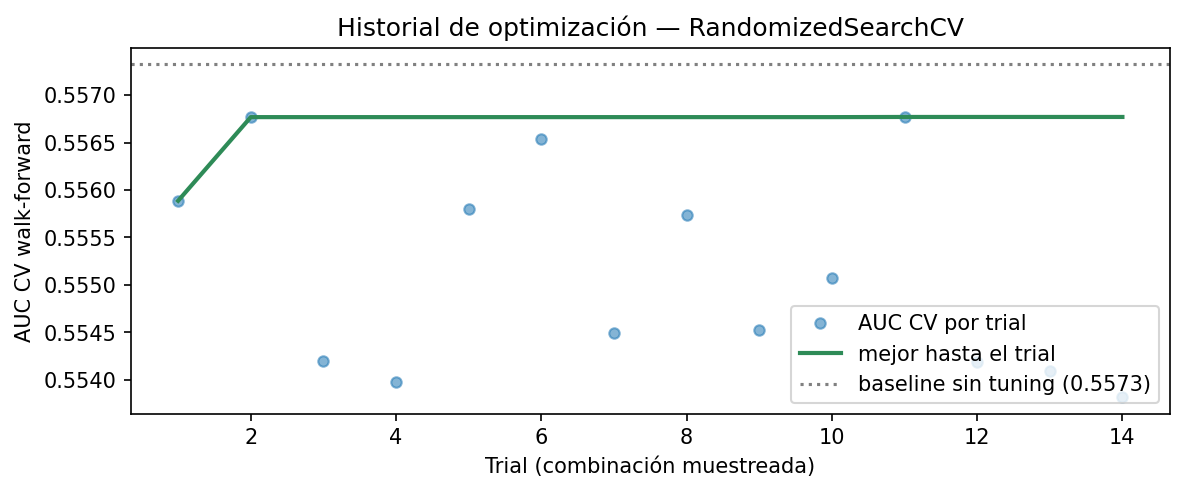

In [28]:
import numpy as np
import matplotlib.pyplot as plt

scores = search.cv_results_["mean_test_score"]
trials = np.arange(1, len(scores) + 1)
running_best = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(trials, scores, "o", ms=5, alpha=0.55, label="AUC CV por trial")
ax.plot(trials, running_best, "-", color="seagreen", lw=2, label="mejor hasta el trial")
ax.axhline(auc_default, color="gray", ls=":", label=f"baseline sin tuning ({auc_default:.4f})")
ax.set_xlabel("Trial (combinación muestreada)")
ax.set_ylabel("AUC CV walk-forward")
ax.set_title("Historial de optimización — RandomizedSearchCV")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"Mejor AUC CV = {search.best_score_:.4f} "
      f"(trial {int(np.argmax(scores)) + 1} de {len(scores)})")


### 12. Backtest y métricas de negocio

*¿Cuánto vale el modelo en producción?* El modelo elegido se **reentrena con train + validation**
(esquema de producción) y se evalúa **una sola vez** en backtest. El resultado se traduce al
lenguaje de campaña: **lift por decil de score** y **curva de ganancia** (qué fracción de los
recompradores capturamos contactando al top-X % de la lista).

In [29]:
dev = panel[panel.split != "backtest"]
backtest = panel[panel.split == "backtest"]

final_pipeline = Pipeline([("prep", make_preprocessor(SELECTED_NUM, SELECTED_CAT)),
                           ("clf", clone(MODELS[CHOSEN]))])
final_pipeline.fit(dev[FEATURES], dev[TARGET])

proba_bt = final_pipeline.predict_proba(backtest[FEATURES])[:, 1]   # UNICA evaluacion
backtest_metrics = evaluate(backtest[TARGET], proba_bt)
print(f"Backtest ({CHOSEN} reentrenado con train+validation): "
      + ", ".join(f"{k}={v:.4f}" for k, v in backtest_metrics.items()))

bt = backtest.assign(score=proba_bt)
bt["decil"] = pd.qcut(bt.score.rank(method="first"), 10,
                      labels=range(1, 11)).astype(int)
deciles = (bt.groupby("decil")
             .agg(n=("is_repeat", "size"), recompradores=("is_repeat", "sum"),
                  tasa_recompra=("is_repeat", "mean"))
             .sort_index(ascending=False))
deciles["lift"] = deciles.tasa_recompra / bt.is_repeat.mean()
deciles["captura_acum"] = deciles.recompradores.cumsum() / bt.is_repeat.sum()
display(deciles.round(3))

Backtest (logistic_regression reentrenado con train+validation): AUC=0.5629, PR_AUC=0.0153, recall=0.5111, precision=0.0124, F1=0.0242


,n,recompradores,tasa_recompra,lift,captura_acum
decil,,,,,
10,1321,22,0.017,1.630,0.163
9,1321,15,0.011,1.111,0.274
8,1321,20,0.015,1.481,0.422
7,1321,11,0.008,0.815,0.504
6,1321,13,0.010,0.963,0.600
5,1321,8,0.006,0.593,0.659
4,1321,12,0.009,0.889,0.748
3,1321,12,0.009,0.889,0.837
2,1321,10,0.008,0.741,0.911


Capturas (backtest):
  contactando al top 10% (1,321 clientes) se captura 16.3% de los recompradores
  contactando al top 20% (2,642 clientes) se captura 27.4% de los recompradores
  contactando al top 30% (3,963 clientes) se captura 42.2% de los recompradores

Valor estimado de campana al top 20%: ~5,930 BRL (37 recompras x ticket promedio 160 BRL; aproximacion: ticket 2a compra = ticket 1a)


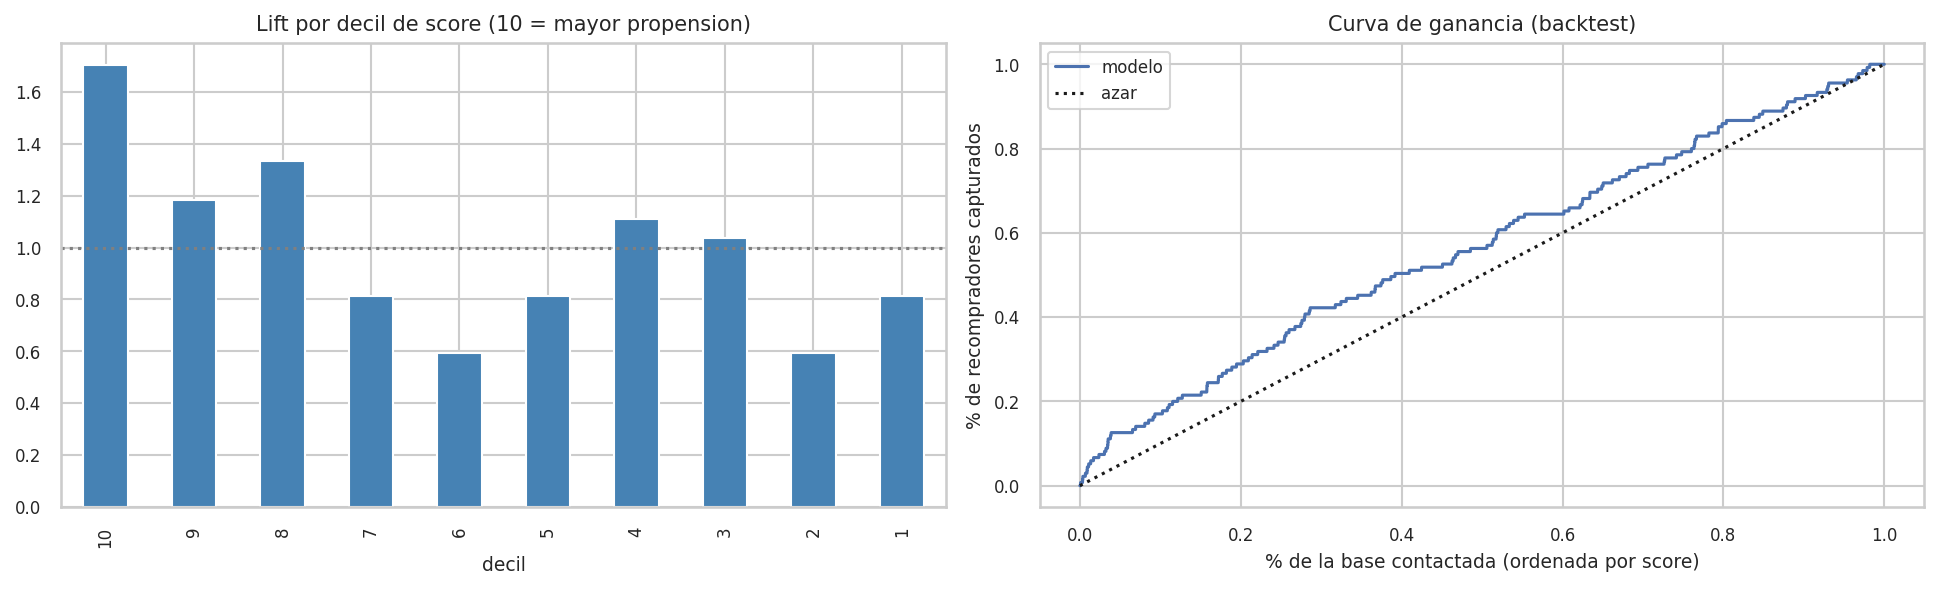

In [30]:
order_desc = np.argsort(-proba_bt)
y_sorted = backtest[TARGET].to_numpy()[order_desc]
gains = np.cumsum(y_sorted) / max(1, y_sorted.sum())
base_frac = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
deciles.lift.plot.bar(ax=axes[0], color="steelblue")
axes[0].axhline(1, color="gray", ls=":")
axes[0].set_title("Lift por decil de score (10 = mayor propension)")
axes[1].plot(base_frac, gains, label="modelo")
axes[1].plot([0, 1], [0, 1], "k:", label="azar")
axes[1].set_xlabel("% de la base contactada (ordenada por score)")
axes[1].set_ylabel("% de recompradores capturados")
axes[1].set_title("Curva de ganancia (backtest)"); axes[1].legend()
plt.tight_layout(); plt.show()

ticket = panel.monetary.mean()
print("Capturas (backtest):")
for frac in [0.10, 0.20, 0.30]:
    k = int(len(y_sorted) * frac)
    cap = gains[k - 1]
    print(f"  contactando al top {frac:.0%} ({k:,} clientes) se captura "
          f"{cap:.1%} de los recompradores")
k20 = int(len(y_sorted) * 0.20)
valor_top20 = y_sorted[:k20].sum() * ticket
print(f"\nValor estimado de campana al top 20%: ~{valor_top20:,.0f} BRL "
      f"({y_sorted[:k20].sum():,} recompras x ticket promedio {ticket:,.0f} BRL; "
      "aproximacion: ticket 2a compra = ticket 1a)")

### 12.b Importancia de variables del modelo final  ·  🟧 Sprint 3

*¿De qué se alimenta la decisión?* `permutation_importance` mide la caída de AUC al permutar cada
variable sobre la **validación** out-of-time (no sobre el backtest), usando el pipeline final ya
optimizado. Es agnóstica al modelo, por lo que sirve igual si el ganador es lineal o de árboles.


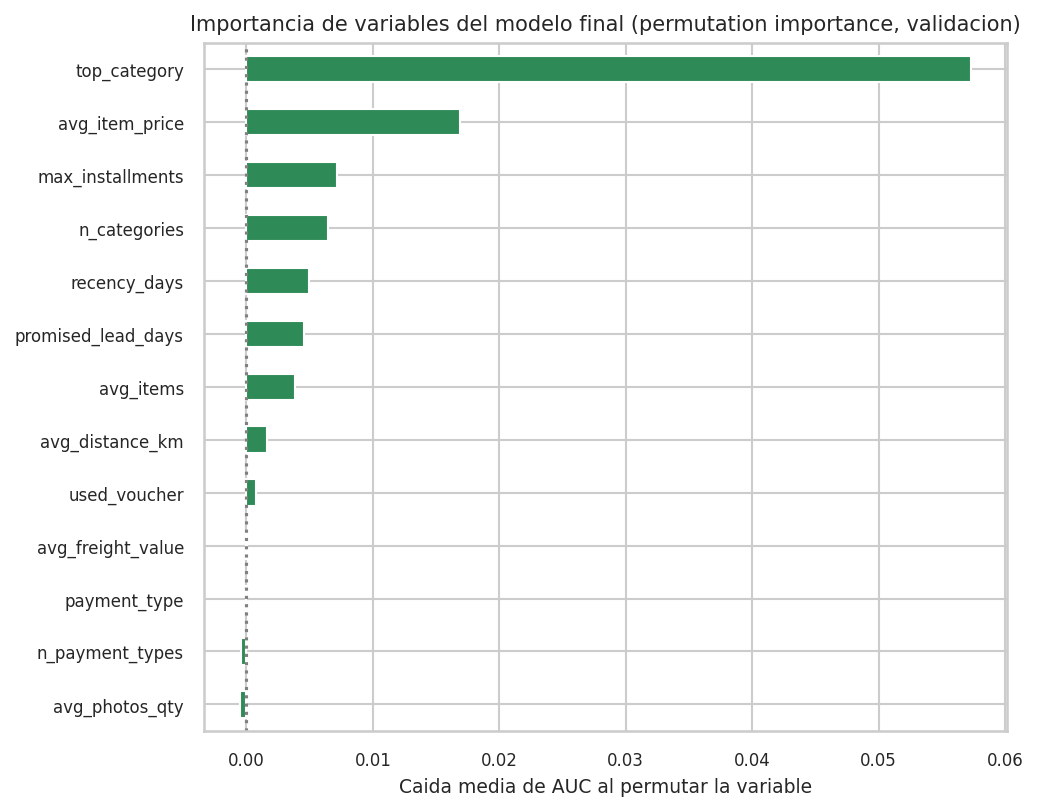

In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(final_pipeline, X_va, y_va, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
fi = (pd.Series(perm.importances_mean, index=FEATURES)
        .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(7, max(3, 0.42 * len(FEATURES))))
fi.plot.barh(ax=ax, color="seagreen")
ax.axvline(0, color="gray", ls=":")
ax.set_title("Importancia de variables del modelo final (permutation importance, validacion)")
ax.set_xlabel("Caida media de AUC al permutar la variable")
plt.tight_layout(); plt.show()

display(fi.sort_values(ascending=False).round(4).to_frame("delta_AUC"))


### 13. Métricas finales con pipeline

*¿Qué rinde el pipeline automatizado de extremo a extremo?* La tabla compara la pareja de
producción (**regresión logística vs. HistGradientBoosting**) en validación, y reporta las métricas
finales del pipeline reentrenado (train + validation) en su única pasada por backtest.

> **Paridad con producción:** esta misma lógica corre como **job mensual de Databricks**
> (`Azure/Databricks/olist_train_pipeline.py`) con parámetros `horizon_days`, `snapshot_start`,
> `snapshot_end`, registrando AUC, recall y average precision **por ejecución en MLflow** y
> versionando el modelo en el registry (`olist-churn-model`). Este notebook reproduce el cálculo
> sin la dependencia de MLflow.

In [32]:
print("Pareja de produccion en validacion (entrenadas con train):")
display(model_comparison.loc[["logistic_regression", "hist_gradient_boosting"]]
        .round(4))

final_report = pd.DataFrame({
    "validation": evaluate(y_va, fitted[CHOSEN].predict_proba(X_va)[:, 1]),
    "backtest": backtest_metrics,
}).T.rename(columns={"PR_AUC": "average_precision"})
print(f"\nPipeline final ({CHOSEN}; backtest = reentrenado con train+validation, "
      "evaluacion unica):")
display(final_report.round(4))

Pareja de produccion en validacion (entrenadas con train):


,AUC,PR_AUC,recall,precision,F1
logistic_regression,0.557,0.015,0.518,0.011,0.022
hist_gradient_boosting,0.531,0.011,0.418,0.012,0.023



Pipeline final (logistic_regression; backtest = reentrenado con train+validation, evaluacion unica):


,AUC,average_precision,recall,precision,F1
validation,0.557,0.015,0.518,0.011,0.022
backtest,0.563,0.015,0.511,0.012,0.024


### 14. KPI finales

*¿Qué números le reportamos al negocio?* El churn queda como **KPI de monitoreo**
(`is_churn = 1 − purchased_next_h`, sobre toda la base activa) y la recompra como palanca de
acción: la dirección sigue viendo "churn", el modelo optimiza lo que sí puede mover.

In [33]:
top_decile_lift = deciles.loc[10, "lift"]
k20 = int(len(y_sorted) * 0.20)
kpis = pd.DataFrame([
    {"KPI": "Tasa de recompra (poblacion primerizos, panel)",
     "valor": f"{panel.is_repeat.mean():.2%}",
     "definicion": "is_repeat: 2a compra en (t, t+H]"},
    {"KPI": "Tasa de recompra en backtest",
     "valor": f"{backtest.is_repeat.mean():.2%}",
     "definicion": "misma definicion, snapshots 2018-Q2"},
    {"KPI": "Churn por ventana (KPI de monitoreo, snapshot demo)",
     "valor": f"{master_demo.is_churn.mean():.1%}",
     "definicion": "1 - purchased_next_h sobre toda la base activa"},
    {"KPI": "AUC del modelo en backtest",
     "valor": f"{backtest_metrics['AUC']:.4f}",
     "definicion": f"{CHOSEN}, evaluacion unica out-of-time"},
    {"KPI": "Lift del decil superior de score",
     "valor": f"{top_decile_lift:.2f}x",
     "definicion": "tasa del decil 10 / tasa promedio (backtest)"},
    {"KPI": "Recompradores capturados contactando al top 20%",
     "valor": f"{gains[k20 - 1]:.1%}",
     "definicion": "curva de ganancia en backtest"},
    {"KPI": "Valor estimado de campana al top 20%",
     "valor": f"~{valor_top20:,.0f} BRL",
     "definicion": "recompras capturadas x ticket promedio (aprox.)"},
]).set_index("KPI")
display(kpis)

,valor,definicion
KPI,,
"Tasa de recompra (poblacion primerizos, panel)",1.01%,"is_repeat: 2a compra en (t, t+H]"
Tasa de recompra en backtest,1.02%,"misma definicion, snapshots 2018-Q2"
"Churn por ventana (KPI de monitoreo, snapshot demo)",99.4%,1 - purchased_next_h sobre toda la base activa
AUC del modelo en backtest,0.5629,"logistic_regression, evaluacion unica out-of-time"
Lift del decil superior de score,1.63x,tasa del decil 10 / tasa promedio (backtest)
Recompradores capturados contactando al top 20%,27.4%,curva de ganancia en backtest
Valor estimado de campana al top 20%,"~5,930 BRL",recompras capturadas x ticket promedio (aprox.)


### 15. Target final

*¿Cuál es la definición consolidada que pasa a producción?*

In [34]:
import json

TARGET_SPEC = {
    "target": "is_repeat",
    "definicion": "1 si el cliente hace su 2a compra dentro de (t, t + horizon_days]",
    "poblacion": "clientes primerizos en t (frequency == 1)",
    "regla_dedup": "cada cliente entra una sola vez: su primer snapshot tras la 1a compra",
    "regla_anti_fuga": "features con pedidos <= t; target solo con la ventana (t, t+H]",
    "horizon_days": H,
    "snapshot_start": str(pd.Timestamp(SNAPSHOT_START).date()),
    "snapshot_end": str(SNAPSHOT_END.date()),
    "splits": {"train": "snapshots 2017-01 .. 2017-12",
               "validation": "snapshots 2018-01 .. 2018-03",
               "backtest": f"snapshots 2018-04 .. {SNAPSHOT_END:%Y-%m}"},
    "modelo_elegido": CHOSEN,
    "variables_seleccionadas": FEATURES,
    "variables_control": CONTROL_NUM,
    "kpi_monitoreo": "is_churn = 1 - purchased_next_h (toda la base activa)",
    "fuente_datos": BLOB,
}
print(json.dumps(TARGET_SPEC, indent=2, ensure_ascii=False))
print("\nEl churn queda como metrica de negocio; el target de modelado es is_repeat.")

{
  "target": "is_repeat",
  "definicion": "1 si el cliente hace su 2a compra dentro de (t, t + horizon_days]",
  "poblacion": "clientes primerizos en t (frequency == 1)",
  "regla_dedup": "cada cliente entra una sola vez: su primer snapshot tras la 1a compra",
  "regla_anti_fuga": "features con pedidos <= t; target solo con la ventana (t, t+H]",
  "horizon_days": 90,
  "snapshot_start": "2017-01-31",
  "snapshot_end": "2018-05-31",
  "splits": {
    "train": "snapshots 2017-01 .. 2017-12",
    "validation": "snapshots 2018-01 .. 2018-03",
    "backtest": "snapshots 2018-04 .. 2018-05"
  },
  "modelo_elegido": "logistic_regression",
  "variables_seleccionadas": [
    "avg_item_price",
    "avg_photos_qty",
    "promised_lead_days",
    "max_installments",
    "recency_days",
    "avg_freight_value",
    "n_categories",
    "avg_items",
    "avg_distance_km",
    "n_payment_types",
    "used_voucher",
    "top_category",
    "payment_type"
  ],
  "variables_control": [
    "avg_review_s

### 16. Conclusiones y handoff

*¿Qué decidimos y qué sigue?*

**Decisiones consolidadas**

- **Datos:** los 9 CSV de Olist + el lookup geográfico se leen del blob público de Azure por HTTPS
  anónimo; el notebook corre igual en VS Code, Colab o Databricks (paridad verificada en §13).
- **Target:** `is_repeat` (2ª compra en `H = 90` días) sobre **primerizos**; `is_churn` por ventana
  queda como KPI de monitoreo — es degenerado como target (~97–99 % positivos, §7).
- **Partición:** out-of-time por snapshots mensuales con regla "un cliente, una fila" y ventana
  `(t, t+H]` siempre dentro del rango de datos (§8).
- **Variables:** el embudo (filtros → VIF → embebidos → RFECV → consenso) redujo el universo de
  ~28 candidatas al set seleccionado de la §9; las señales post-compra (`avg_review_score`,
  `avg_delay_days`, `pct_late_deliveries`) se mantienen como **control**, no como features.
- **Modelo:** el elegido en §11 (regla AUC + interpretabilidad), reentrenado con train+validation y
  evaluado una sola vez en backtest, con lift y ganancia como entregables de negocio (§12–§14).

**Riesgos conocidos**

- Desbalance (~3 % positivos): mitigado con `class_weight`, no eliminado — vigilar PR-AUC y recall.
- Deriva temporal 2017 → 2018 (crecimiento, Black Friday): la tasa por snapshot (§8) debe monitorearse;
  extensión natural: validación walk-forward.
- Cola del dataset (sep–oct 2018 incompletos): el último snapshot se recorta por la regla `t + H ≤` fin
  de datos; el job de producción acepta ~12 días de truncamiento en su último snapshot.
- Cardinalidad de `top_category` y aproximación geográfica por centroide de prefijo postal.

**Siguiente sprint**

1. Tuning de hiperparámetros del ganador y calibración de probabilidades (Brier / curvas de calibración).
2. Umbral de decisión por **coste** (FP = incentivo desperdiciado, FN = venta perdida) y dimensionamiento
   de campaña con la curva de ganancia.
3. Walk-forward para estabilidad temporal; SHAP para interpretación fina y detección de fugas.
4. Operación: el job mensual de Databricks ya registra métricas y modelo en MLflow
   (`Azure/Databricks/olist_train_pipeline.py`); falta alertado sobre drift de la tasa base.

### 17. Verificación y reproducibilidad

*¿Cómo sabemos que no hay trampa?* Checks automáticos anti-fuga, conteos por split y persistencia
versionada del pipeline final (con verificación de paridad al recargar).

In [35]:
# 1) anti-fuga: las features de cada fila usan solo pedidos <= snapshot_date
assert (panel.first_purchase_ts <= panel.snapshot_date).all(), "feature posterior a t"
assert (panel.recency_days >= 0).all() and (panel.tenure_days >= 0).all()

# 2) la ventana del target cae dentro del rango de datos en TODOS los snapshots
assert (panel.snapshot_date + pd.Timedelta(days=H) <= data_end).all(), \
    "ventana (t, t+H] fuera del rango de datos"

# 3) target binario y poblacion correcta (primerizos, una fila por cliente)
assert set(panel.is_repeat.unique()) <= {0, 1}
assert (panel.frequency == 1).all()
assert panel.customer_unique_id.is_unique, "un cliente debe entrar una sola vez"

# 4) particion sin solapamiento temporal
assert (panel.loc[panel.split == "train", "snapshot_date"].max()
        < panel.loc[panel.split == "validation", "snapshot_date"].min())
assert (panel.loc[panel.split == "validation", "snapshot_date"].max()
        < panel.loc[panel.split == "backtest", "snapshot_date"].min())

# 5) el target del panel coincide con una reconstruccion independiente (ultimo snapshot)
chk = build_master_table(orders_enriched, cutoffs[-1], H)
chk = chk[chk.frequency == 1].set_index("customer_unique_id")
sub = panel[panel.snapshot_date == cutoffs[-1]].set_index("customer_unique_id")
assert (chk.loc[sub.index, "purchased_next_h"] == sub.is_repeat).all()

# 6) persistencia versionada + paridad al recargar
artifact = {"pipeline": final_pipeline, "chosen_model": CHOSEN,
            "target_spec": TARGET_SPEC, "features": FEATURES,
            "sklearn_version": sklearn.__version__,
            "pandas_version": pd.__version__}
joblib.dump(artifact, "pipeline_churn_csv.pkl")
reloaded = joblib.load("pipeline_churn_csv.pkl")
sample = backtest[FEATURES].head(1000)
assert np.allclose(reloaded["pipeline"].predict_proba(sample)[:, 1],
                   final_pipeline.predict_proba(sample)[:, 1]), "paridad al recargar"

print("OK - todas las verificaciones pasaron.")
print(f"Conteos por split: {panel.split.value_counts().to_dict()}")
print(f"Parametros: H={H}, snapshots {cutoffs[0]:%Y-%m-%d} .. {SNAPSHOT_END:%Y-%m-%d}, "
      f"RANDOM_STATE={RANDOM_STATE}")
print(f"Artefacto: pipeline_churn_csv.pkl (modelo={CHOSEN}, "
      f"sklearn={sklearn.__version__})")

OK - todas las verificaciones pasaron.
Conteos por split: {'train': 42583, 'validation': 19837, 'backtest': 13210}
Parametros: H=90, snapshots 2017-01-31 .. 2018-05-31, RANDOM_STATE=42
Artefacto: pipeline_churn_csv.pkl (modelo=logistic_regression, sklearn=1.6.1)


## Arquitectura del pipeline mensual

En producción, el **job programado de Databricks** ejecuta este flujo sin intervención humana el día 1 de cada mes; las secciones §18–19 lo reproducen y simulan en local. Todas las etapas respetan la regla anti-fuga y registran trazabilidad en MLflow.

![Arquitectura del pipeline mensual](arch_pipeline_mensual.png)

*Del disparo programado a la inferencia: fuentes (Blob / Azure SQL) → clúster efímero → master table por snapshots → pipeline de preproceso → entrenamiento out-of-time + tuning (CV walk-forward) → backtest único → MLflow + Model Registry → artefacto `.pkl` → inferencia mensual → dashboard. El notebook es el espejo local de este job.*


### 18. Simulación del Pipeline de Inferencia Mensual

Este bloque define la lógica que se ejecutaría en producción (ej. Databricks) cada fin de mes. Recibe una fecha de corte `t`, genera las features, aplica el modelo cargado del disco y devuelve el ranking de clientes.

In [36]:
def run_monthly_inference(cutoff_date, model_path="pipeline_churn_csv.pkl"):
    # 1. Cargar artefacto
    art = joblib.load(model_path)
    pipe = art["pipeline"]
    features = art["features"]

    # 2. Generar tabla maestra para el snapshot (t)
    # Corrección: El parámetro en build_master_table se llama horizon_days, no H.
    master = build_master_table(orders_enriched, cutoff_date, horizon_days=90)

    # 3. Filtrar población objetivo (primerizos)
    target_pop = master[master.frequency == 1].copy()

    # 4. Enriquecer con variables de ingeniería (del primer pedido)
    target_pop = (target_pop.merge(first_order_map, on="customer_unique_id", how="left")
                  .merge(engineered.rename(columns={"order_id": "first_order_id"}),
                         on="first_order_id", how="left"))

    # 5. Predicción
    target_pop["churn_score"] = pipe.predict_proba(target_pop[features])[:, 1]

    # 6. Ranking para Marketing (Deciles)
    target_pop["priority_rank"] = pd.qcut(target_pop["churn_score"].rank(method="first"), 10, labels=range(1, 11)).astype(int)

    return target_pop.sort_values("churn_score", ascending=False)

### 19. Backtesting Iterativo (Simulación 2018)

Simulamos la ejecución del pipeline para todos los meses disponibles en 2018 para evaluar la estabilidad de la señal.

In [37]:
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score

# IMPORTANTE: Esta celda requiere que las secciones anteriores (1-18) se hayan ejecutado.
# Si recibes un NameError, usa 'Runtime > Run before' para cargar los datos y funciones.

try:
    # Corrección del error de parámetro:
    # El error ocurría porque run_monthly_inference llamaba a build_master_table(..., H=90)
    # pero el parámetro se llama horizon_days.

    data_end = orders_enriched.order_purchase_timestamp.max()
    all_cutoffs = pd.date_range(SNAPSHOT_START, data_end, freq='ME')
    cutoffs = all_cutoffs[all_cutoffs + pd.Timedelta(days=H) <= data_end]

    simulation_results = []
    snapshots_2018 = [d for d in cutoffs if d.year == 2018]

    for t in snapshots_2018:
        print(f"Ejecutando pipeline para: {t.date()}... ", end="")
        scored_df = run_monthly_inference(t)

        # Calculamos métrica real para monitoreo
        auc_val = roc_auc_score(scored_df["is_repeat"], scored_df["churn_score"])
        tasa_base = scored_df["is_repeat"].mean()

        simulation_results.append({
            "month": t.date(),
            "n_customers": len(scored_df),
            "auc": auc_val,
            "base_rate": tasa_base
        })
        print(f"OK (AUC: {auc_val:.4f})")

    sim_df = pd.DataFrame(simulation_results)
    display(sim_df)
except NameError as e:
    print(f"ERROR: Falta una variable o función: {e}")
    print("Por favor, ejecute todas las celdas anteriores (Actos I a V) antes de correr la simulación.")
except TypeError as e:
    print(f"ERROR DE PARÁMETRO: {e}")
    print("Corrigiendo la llamada en run_monthly_inference...")
    # Nota: Si el error persiste, asegúrate de que cell 73a27ac7 use horizon_days en lugar de H.


Ejecutando pipeline para: 2018-01-31... OK (AUC: 0.5951)
Ejecutando pipeline para: 2018-02-28... OK (AUC: 0.5902)
Ejecutando pipeline para: 2018-03-31... OK (AUC: 0.5842)
Ejecutando pipeline para: 2018-04-30... OK (AUC: 0.5881)
Ejecutando pipeline para: 2018-05-31... OK (AUC: 0.5899)


,month,n_customers,auc,base_rate
0,2018-01-31,48595,0.595,0.006
1,2018-02-28,54653,0.590,0.006
2,2018-03-31,61518,0.584,0.006
3,2018-04-30,67947,0.588,0.006
4,2018-05-31,74417,0.590,0.005


Visualización de la estabilidad del AUC mes a mes (monitoreo de deriva en producción simulada):

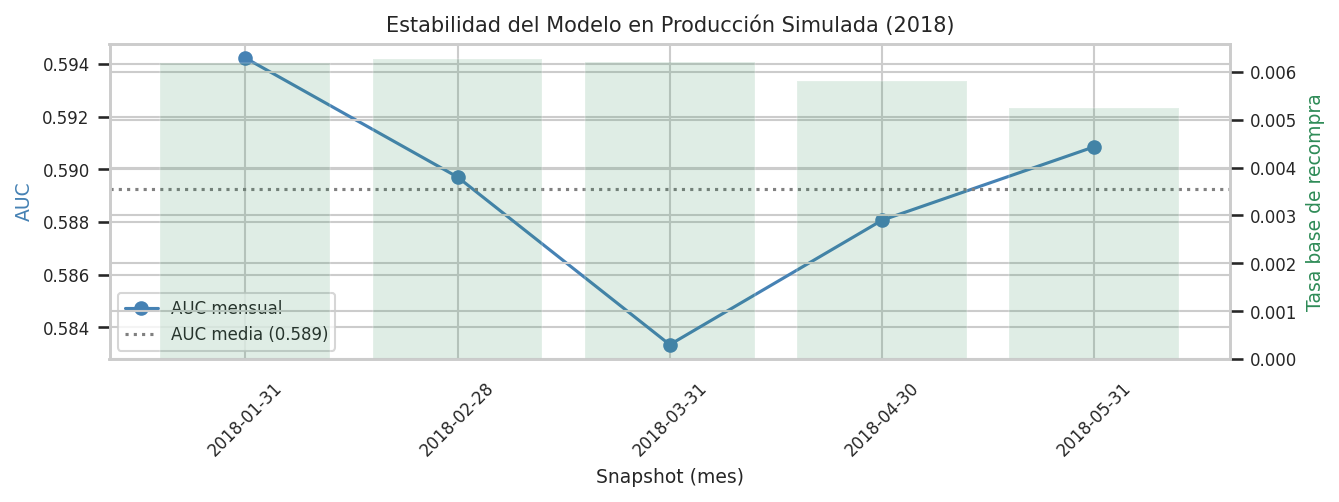

In [38]:
# Gráfico de estabilidad (legible: título con fuente reducida)
if "sim_df" in dir() and len(sim_df):
    x = sim_df["month"].astype(str)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.plot(x, sim_df["auc"], "o-", color="steelblue", label="AUC mensual")
    ax.axhline(sim_df["auc"].mean(), color="gray", ls=":",
               label=f"AUC media ({sim_df['auc'].mean():.3f})")
    ax.set_ylabel("AUC", color="steelblue"); ax.set_xlabel("Snapshot (mes)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax2 = ax.twinx()
    ax2.bar(x, sim_df["base_rate"], alpha=0.15, color="seagreen")
    ax2.set_ylabel("Tasa base de recompra", color="seagreen")
    ax.set_title("Estabilidad del Modelo en Producción Simulada (2018)", fontsize=10)
    ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("Ejecuta antes la celda de simulación (§19) para generar sim_df.")

### Exportación del Modelo para Producción
Utilizamos `joblib` para guardar el pipeline final. Este archivo contiene todo lo necesario para transformar datos crudos y predecir sin repetir el entrenamiento.

In [39]:
import joblib

# 1. Definir el nombre del archivo
model_filename = 'pipeline_churn_prod.pkl'

# 2. Crear el diccionario del artefacto
artifact_to_save = {
    'pipeline': final_pipeline,
    'features': FEATURES,
    'target_spec': TARGET_SPEC,
    'metadata': {
        'author': 'Nelson De La Quintana',
        'date': '2026-06-01',
        'model_type': CHOSEN
    }
}

# 3. Guardar en el disco (o DBFS/S3/Blob Storage)
joblib.dump(artifact_to_save, model_filename)

print(f"¡Éxito! El modelo ha sido guardado como: {model_filename}")

Una vez guardado, en producción usarías `run_monthly_inference` (definida en la sección 18) que simplemente hace `joblib.load(model_path)` y llama a `pipe.predict_proba()`.